# Real World Classification

## Load data

Import the necessary libraries

In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

c:\Users\janas\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\janas\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


load the data

In [2]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head(72)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,68,7.7,NaN,NaN,2.2,17.8,80.2,7.472668,7.864016,7.794105,...,2.428947,-0.412250,0.358726,1.686544,1.754858,0.321667,2.267802,-0.214535,0.572119,Iris-virginica
68,69,NaN,NaN,6.900000,2.3,NaN,7.5,6.316422,6.323365,6.320980,...,1.392999,0.036731,-0.938834,-0.181394,1.032778,0.507191,0.963030,-2.005843,0.513756,Iris-virginica
69,70,6.0,2.2,5.000000,1.5,16.0,98.7,5.712541,6.029193,5.742271,...,0.389917,0.655273,1.475858,0.467120,1.308018,0.781909,0.834278,0.249789,1.469573,Iris-virginica
70,71,NaN,NaN,NaN,2.3,NaN,77.2,6.316422,6.323365,6.320980,...,0.469544,1.970540,-0.076459,0.145849,-0.618336,0.195841,0.440834,-2.878216,-1.321907,Iris-virginica


In [3]:
feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]
#show median and standard deviaton for columns which have missing values
na_cols = df[feature_cols].columns[df[feature_cols].isnull().any()]
print(na_cols)
print("Median and Standard Deviation befor data processing")
for col in na_cols:
    print(f"{col}: median = {df[col].median():.4f}, std = {df[col].std():.4f}")


Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'BranchLength'],
      dtype='str')
Median and Standard Deviation befor data processing
SepalLengthCm: median = 6.3000, std = 1.0371
SepalWidthCm: median = 2.9000, std = 0.3896
PetalLengthCm: median = 5.0856, std = 1.5828
PetalWidthCm: median = 1.6000, std = 0.7067
BranchLength: median = 16.3000, std = 1.0352


## Data Preprocessing

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)


In [5]:
#print meduan and standard deviation
print("Median and Mean for Columns with NAs after Nearest Neighbors Imputation")
for col in na_cols:
    print(f"{col}: median = {df[col].median():.4f}, std = {df[col].std():.4f}")

Median and Mean for Columns with NAs after Nearest Neighbors Imputation
SepalLengthCm: median = 6.3000, std = 1.0093
SepalWidthCm: median = 2.9000, std = 0.3724
PetalLengthCm: median = 5.0357, std = 1.5150
PetalWidthCm: median = 1.7000, std = 0.6946
BranchLength: median = 16.3000, std = 1.0110


In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

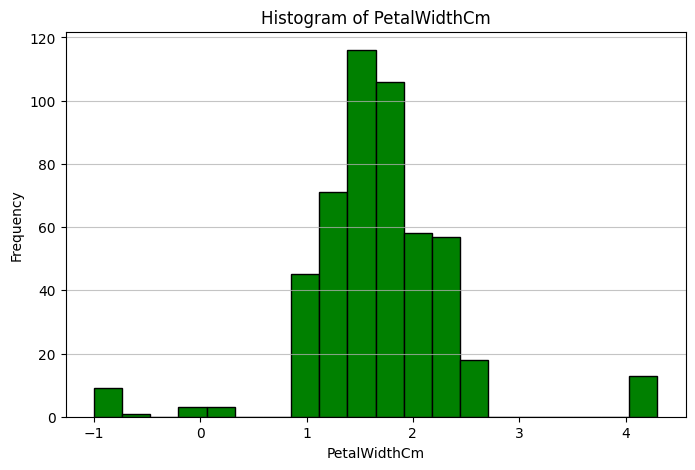

Largest Positive Correlation with PetalWidthCm
PetalWidthCompactness: 0.9917

Top 5 Strongest Negative Correlations with PetalWidthCm
SepalWidthMajorAxis: -0.0964
SepalGlossIndex: -0.0952
SepalWidthCompactness: -0.0885
SepalWidthCurvature: -0.0813
SepalWidthMinorAxis: -0.0744


In [7]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration
#4a histogram

plt.figure(figsize=(8, 5))
plt.hist(df['PetalWidthCm'], bins=20, color='green', edgecolor='black')
plt.title('Histogram of PetalWidthCm')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

#4b
#exclude variables PetalWidthCm, Species, and Id
excluded_col = ['PetalWidthCm', 'Species', 'Id']
candidate_col = [c for c in df.columns if c not in excluded_col]

X_corr = df[candidate_col]
y_corr = df['PetalWidthCm']

# Compute Pearson correlation
corr = r_regression(X_corr, y_corr)
corr_series = pd.Series(corr, index=candidate_col).sort_values(ascending=False)

# 4(b) - Feature with largest positive correlation
highest_positive = corr_series.iloc[0]
print("Largest Positive Correlation with PetalWidthCm")
print(f"{corr_series.index[0]}: {highest_positive:.4f}")

# 4(c) - Top 5 strongest negative correlations
negative = corr_series.nsmallest(5)
print("\nTop 5 Strongest Negative Correlations with PetalWidthCm")
for feat, val in negative.items():
    print(f"{feat}: {val:.4f}")

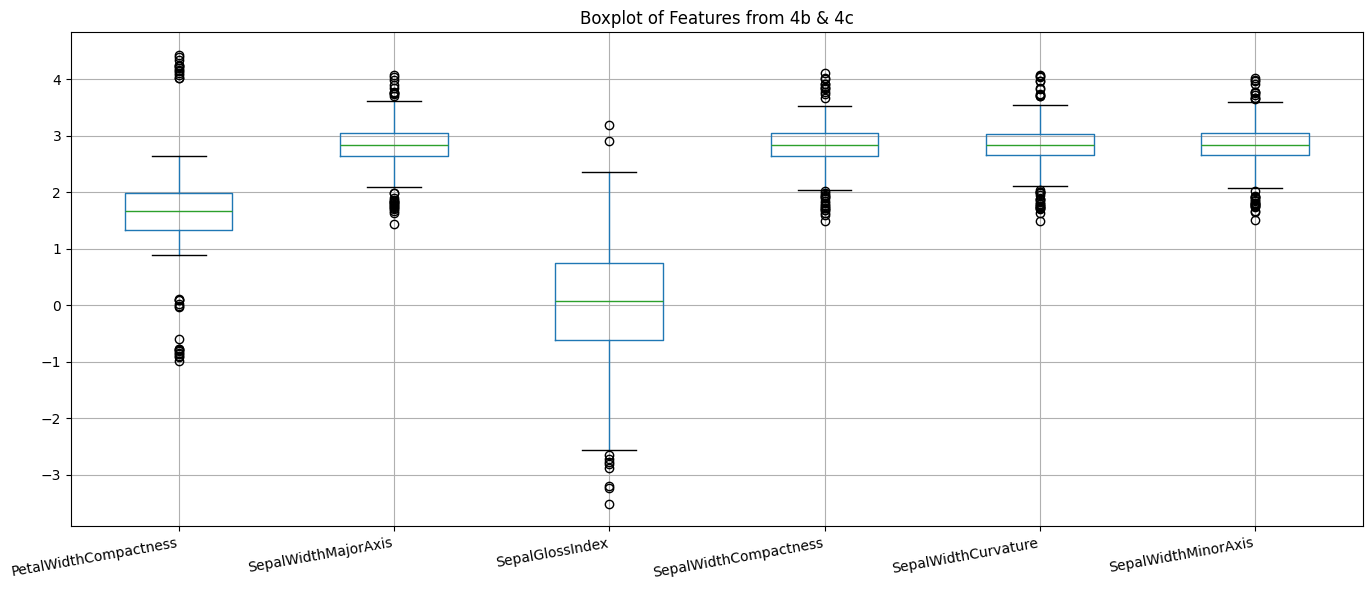

In [8]:
# 4 d) Boxplot for features 
positive_feature = [corr_series.index[0]]
negative_features = list(negative.index)
plot_features = positive_feature + negative_features

plt.figure(figsize=(14, 6))
df[plot_features].boxplot()
plt.title('Boxplot of Features from 4b & 4c')
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.show()

## Model Training

### Prepare the data

In [9]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

50. Training loss: 0.6750694290943433, Val loss:0.6840309642470094
100. Training loss: 0.6747548127534178, Val loss:0.6839309748933531
150. Training loss: 0.6747488372001222, Val loss:0.6839298599003173
200. Training loss: 0.6747487203171995, Val loss:0.6839298551190556
250. Training loss: 0.6747487180286232, Val loss:0.6839298554515596
300. Training loss: 0.6747487179838312, Val loss:0.6839298554687433
350. Training loss: 0.6747487179829557, Val loss:0.6839298554693461
400. Training loss: 0.6747487179829386, Val loss:0.6839298554693646
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
750. Training loss: 0.6747487179829382, Val loss:0

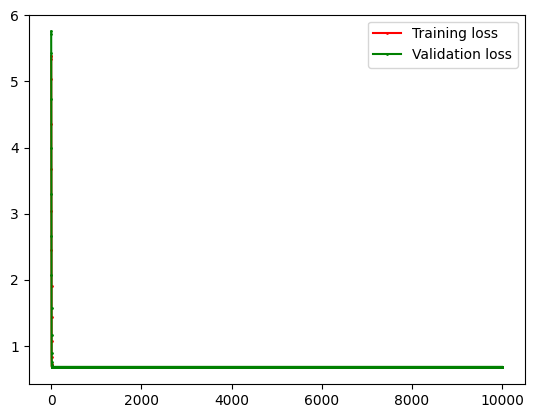

Model parameters (weights): [[-0.01249206]
 [ 0.02228109]
 [ 0.00731174]
 [ 0.02160094]
 [ 0.03647292]
 [ 0.01868654]
 [ 0.01769178]
 [ 0.01789019]
 [ 0.01923883]
 [ 0.02027882]
 [ 0.01914643]
 [ 0.02013799]
 [ 0.02095232]
 [ 0.00458568]
 [ 0.00311998]
 [ 0.00605684]
 [ 0.00705284]
 [ 0.00742952]
 [ 0.00627274]
 [ 0.02328098]
 [ 0.02385686]
 [ 0.02565637]
 [ 0.02391417]
 [ 0.02520387]
 [ 0.02375411]
 [ 0.03462815]
 [ 0.03522777]
 [ 0.03662822]
 [ 0.03649798]
 [ 0.036714  ]
 [ 0.03671077]
 [-0.01304758]
 [ 0.00456383]
 [-0.00644573]
 [-0.00238571]
 [-0.00519696]
 [-0.00335385]
 [-0.0124363 ]
 [-0.02754184]
 [-0.00523545]
 [-0.00983527]
 [-0.0041134 ]
 [-0.01539004]
 [-0.00700335]
 [-0.0017571 ]
 [-0.00552268]
 [-0.00863107]
 [-0.00523874]
 [-0.01145154]
 [-0.00881981]
 [-0.00133932]
 [-0.00757033]
 [-0.00632656]
 [-0.0080036 ]
 [-0.00210421]
 [-0.00160616]
 [-0.00839356]
 [-0.01317914]
 [-0.00861225]
 [-0.01061584]
 [-0.01525315]
 [-0.00042755]
 [ 0.00442472]
 [-0.01255564]
 [-0.0094437

In [10]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='l2', reg_lambda=100)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.5067
Precision : 0.5067
Recall    : 1.0000
F1-score  : 0.6726


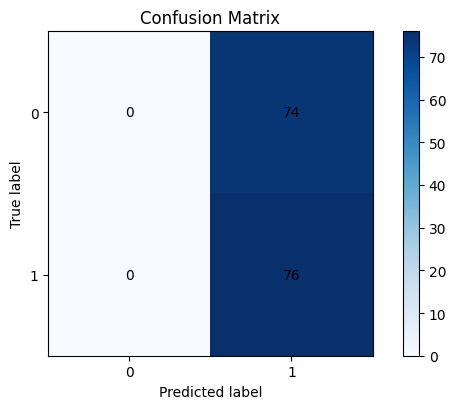

{'Accuracy': 0.5066666666666667,
 'Precision': 0.5066666666666667,
 'Recall': 1.0,
 'F1-score': 0.672566371681416}

In [11]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)

#Assignment 2 

#1a)

50. Training loss: 5.509762401121144, Val loss:5.509762401121144
100. Training loss: 5.458964536043911, Val loss:5.455831782322393
150. Training loss: 4.896449387204859, Val loss:4.8775585639488765
200. Training loss: 3.90549471161231, Val loss:3.885561927143239
250. Training loss: 2.9123495662605676, Val loss:2.8926113487718617
300. Training loss: 1.9463248316547193, Val loss:1.9278119212152725
350. Training loss: 1.139822191924772, Val loss:1.1274670435639125
400. Training loss: 0.7646069930339863, Val loss:0.7613668297284761
450. Training loss: 0.6910371564797486, Val loss:0.690579886871337
500. Training loss: 0.6802968294223779, Val loss:0.6802074940178422


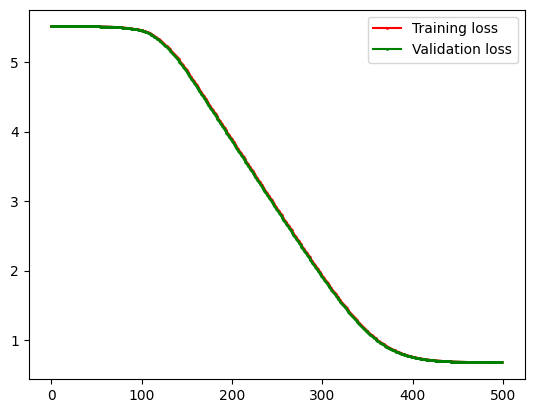

50. Training loss: 5.386409735425521, Val loss:5.386409735425521
100. Training loss: 5.321875060658375, Val loss:5.319022235035614
150. Training loss: 4.81956928819391, Val loss:4.802954617454679
200. Training loss: 3.8914683604968436, Val loss:3.8725980639245003
250. Training loss: 2.9508426281247573, Val loss:2.9321292412199838
300. Training loss: 2.0307264141786274, Val loss:2.0129139278855317
350. Training loss: 1.2281694260212634, Val loss:1.2150245221359581
400. Training loss: 0.7931921970675642, Val loss:0.7888974260141193
450. Training loss: 0.6908333707187387, Val loss:0.6901620503364416
500. Training loss: 0.6753474425708939, Val loss:0.6752290745650176


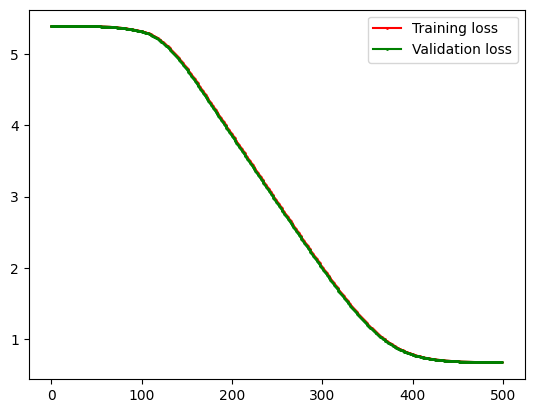

50. Training loss: 5.4275272906573955, Val loss:5.4275272906573955
100. Training loss: 5.363553826620536, Val loss:5.360526061769486
150. Training loss: 4.862013779701411, Val loss:4.844448871772393
200. Training loss: 3.9000803593222138, Val loss:3.880614345506056
250. Training loss: 2.9299815546952526, Val loss:2.9106919365515305
300. Training loss: 1.9838404499096864, Val loss:1.965622006470576
350. Training loss: 1.1778944606580637, Val loss:1.165170284451345
400. Training loss: 0.7774891890874174, Val loss:0.7738414094746227
450. Training loss: 0.6933668971375202, Val loss:0.6928385516017869
500. Training loss: 0.6811974337257849, Val loss:0.6811024202544379


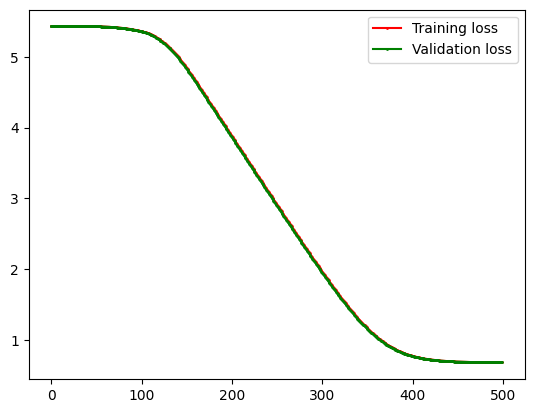

50. Training loss: 5.591997511584893, Val loss:5.591997511584893
100. Training loss: 5.531667353395081, Val loss:5.528307417166751
150. Training loss: 4.937751377673045, Val loss:4.91824557997302
200. Training loss: 3.9176766083593213, Val loss:3.8972233212101157
250. Training loss: 2.8989596806500613, Val loss:2.878728843554121
300. Training loss: 1.912016751384475, Val loss:1.893232217967948
350. Training loss: 1.110142137706511, Val loss:1.0983232981197364
400. Training loss: 0.7649307441580087, Val loss:0.7621082920552066
450. Training loss: 0.7014696905251946, Val loss:0.7010720152598027
500. Training loss: 0.6917325153837772, Val loss:0.691642423909704


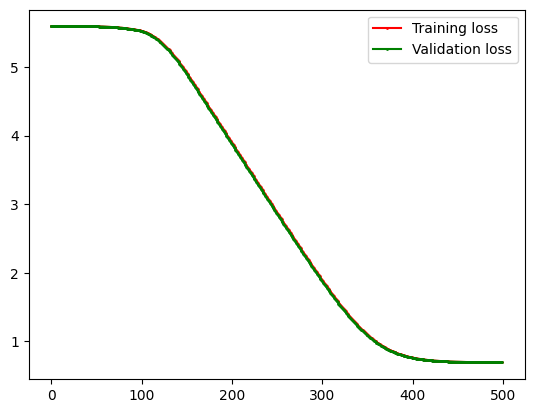

50. Training loss: 5.386409735425521, Val loss:5.386409735425521
100. Training loss: 5.327895077706518, Val loss:5.324867682543251
150. Training loss: 4.837377736881445, Val loss:4.820884758390098
200. Training loss: 3.90556823480294, Val loss:3.886654055344036
250. Training loss: 2.96267554611236, Val loss:2.9439141287240864
300. Training loss: 2.0397752657536063, Val loss:2.02189435259537
350. Training loss: 1.2327596857167058, Val loss:1.2195083975735976
400. Training loss: 0.7936949566891033, Val loss:0.7893614976363403
450. Training loss: 0.6907453842438387, Val loss:0.6900760506724667
500. Training loss: 0.675409700754251, Val loss:0.6752941145705557


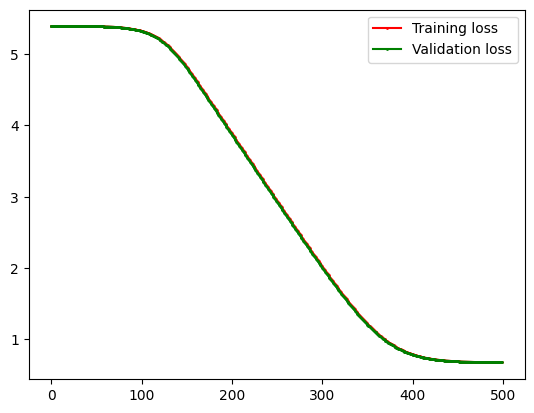

lr=0.005, λ=1.0 → avg accuracy=0.5514
50. Training loss: 5.509762401121144, Val loss:5.509762401121144
100. Training loss: 5.455184581523638, Val loss:5.451598737555632
150. Training loss: 4.864397778949377, Val loss:4.845091009304208
200. Training loss: 3.86390024953326, Val loss:3.8438331270272563
250. Training loss: 2.865195143615307, Val loss:2.845375514286419
300. Training loss: 1.8981589867764552, Val loss:1.8797281021620604
350. Training loss: 1.1061789331912548, Val loss:1.0943449776362837
400. Training loss: 0.7554761881382941, Val loss:0.7525504236897588
450. Training loss: 0.6896073814612858, Val loss:0.6891999411484749
500. Training loss: 0.6799211336257658, Val loss:0.6798376023800097


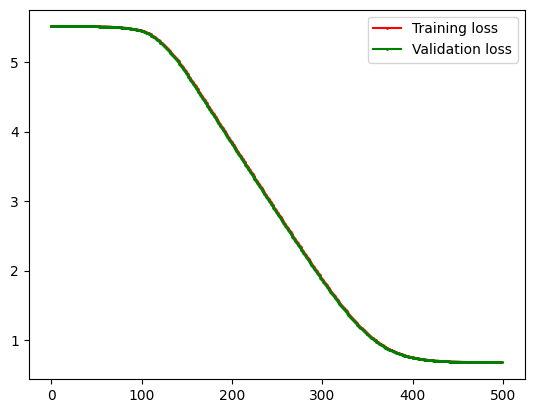

50. Training loss: 5.386409735425521, Val loss:5.386409735425521
100. Training loss: 5.31835925564012, Val loss:5.315359060435068
150. Training loss: 4.790546870648213, Val loss:4.7735801794764825
200. Training loss: 3.8507187810532693, Val loss:3.8317142472578896
250. Training loss: 2.9044339848463365, Val loss:2.8856336455158336
300. Training loss: 1.9824361079384578, Val loss:1.9646660885652694
350. Training loss: 1.1907275426960646, Val loss:1.1780225664586734
400. Training loss: 0.780631047177043, Val loss:0.7767284323842194
450. Training loss: 0.6887789005479783, Val loss:0.6881837663810157
500. Training loss: 0.6749549708969029, Val loss:0.6748462714831237


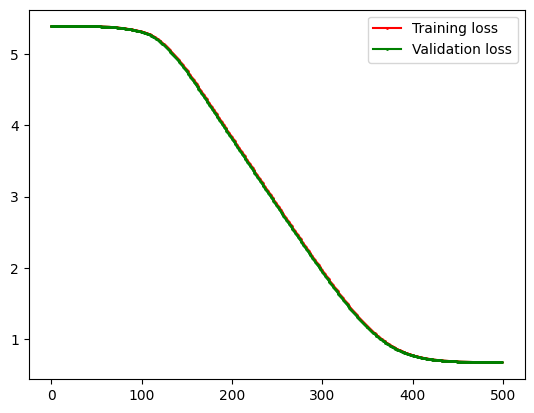

50. Training loss: 5.4275272906573955, Val loss:5.4275272906573955
100. Training loss: 5.3599138807964986, Val loss:5.35675137292364
150. Training loss: 4.8315850506915465, Val loss:4.813390068219354
200. Training loss: 3.8588514247138734, Val loss:3.83925106784633
250. Training loss: 2.883143752393078, Val loss:2.863770062235416
300. Training loss: 1.9355790027030224, Val loss:1.9174240555499336
350. Training loss: 1.1425339722274257, Val loss:1.1302987750928335
400. Training loss: 0.7669878100854092, Val loss:0.7636875608661462
450. Training loss: 0.6916643633655016, Val loss:0.6911952543744696
500. Training loss: 0.6807556568068459, Val loss:0.6806675851956364


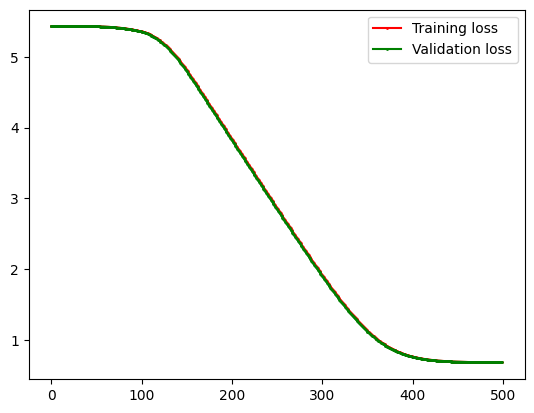

50. Training loss: 5.591997511584893, Val loss:5.591997511584893
100. Training loss: 5.527707124670409, Val loss:5.524105568432697
150. Training loss: 4.905130897035958, Val loss:4.885287479775523
200. Training loss: 3.875632679540182, Val loss:3.855044937216711
250. Training loss: 2.851414945996451, Val loss:2.8311061886530102
300. Training loss: 1.8640128006567653, Val loss:1.845334753027011
350. Training loss: 1.0785308563777878, Val loss:1.0672609936736093
400. Training loss: 0.7569788198808988, Val loss:0.7544323848619163
450. Training loss: 0.7000664539892044, Val loss:0.6997094275003684
500. Training loss: 0.6911741445243257, Val loss:0.6910884328014854


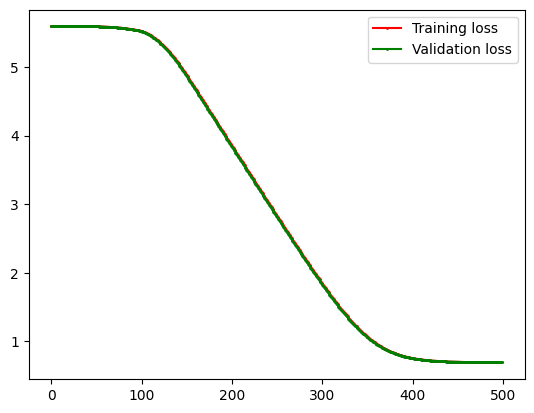

50. Training loss: 5.386409735425521, Val loss:5.386409735425521
100. Training loss: 5.324162298150915, Val loss:5.321000474766583
150. Training loss: 4.808524861283458, Val loss:4.791562635076725
200. Training loss: 3.864686860229149, Val loss:3.8456378770903794
250. Training loss: 2.9161020468626764, Val loss:2.8972528108247046
300. Training loss: 1.9912473035093066, Val loss:1.9734065357195134
350. Training loss: 1.1949689208796601, Val loss:1.1821576416793729
400. Training loss: 0.7809975494786988, Val loss:0.7770615316150409
450. Training loss: 0.6886801693952042, Val loss:0.6880874807339927
500. Training loss: 0.6750076621337033, Val loss:0.6749016150788516


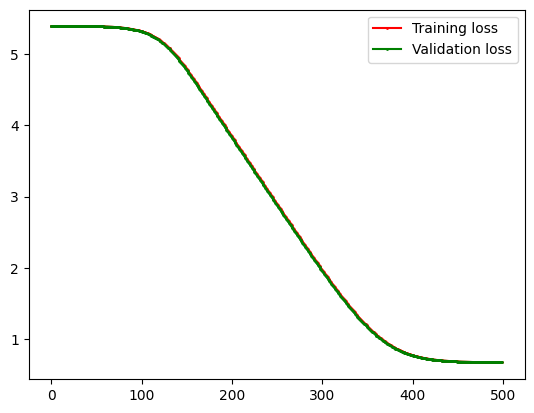

lr=0.005, λ=2.0 → avg accuracy=0.5543
50. Training loss: 5.509762401121144, Val loss:5.509762401121144
100. Training loss: 5.4464081484349585, Val loss:5.44204858042592
150. Training loss: 4.799763138031303, Val loss:4.779681218120146
200. Training loss: 3.7816988089262655, Val loss:3.7613723403607113
250. Training loss: 2.7724487909011524, Val loss:2.752481704139176
300. Training loss: 1.804765969542042, Val loss:1.7865471969885276
350. Training loss: 1.044714214099385, Val loss:1.0339447069058574
400. Training loss: 0.7401353285617142, Val loss:0.7377531649427828
450. Training loss: 0.6872369090762813, Val loss:0.68691085469133
500. Training loss: 0.6792642473102624, Val loss:0.6791901495573255


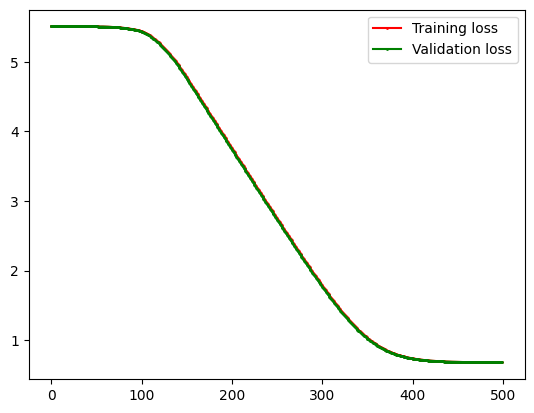

50. Training loss: 5.386409735425521, Val loss:5.386409735425521
100. Training loss: 5.310591130175396, Val loss:5.306754730480714
150. Training loss: 4.730439930411431, Val loss:4.712187513480109
200. Training loss: 3.7701824093599297, Val loss:3.750918465653576
250. Training loss: 2.8131253766020894, Val loss:2.7941652020476275
300. Training loss: 1.8885471816350552, Val loss:1.870902439717359
350. Training loss: 1.1214412962615143, Val loss:1.1096645156244351
400. Training loss: 0.7593825391219994, Val loss:0.756172310283656
450. Training loss: 0.6854255000019704, Val loss:0.6849548838080399
500. Training loss: 0.6742977941802201, Val loss:0.6742047001781084


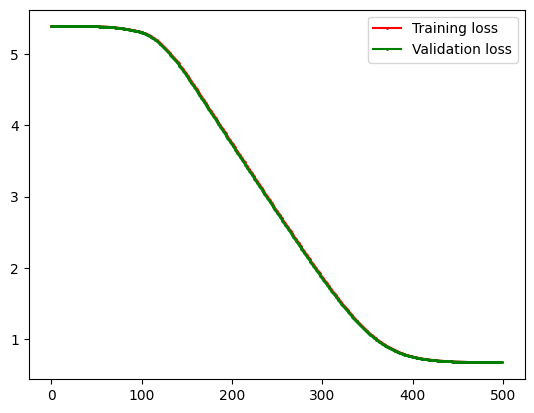

50. Training loss: 5.4275272906573955, Val loss:5.4275272906573955
100. Training loss: 5.352076721504561, Val loss:5.348480468359484
150. Training loss: 4.769969255276355, Val loss:4.750972543934724
200. Training loss: 3.7773701672157003, Val loss:3.757510332439039
250. Training loss: 2.7910059491306596, Val loss:2.7714788611168695
300. Training loss: 1.8418803953017846, Val loss:1.8238970500724239
350. Training loss: 1.0775687573130324, Val loss:1.0663464162868774
400. Training loss: 0.7492981886359512, Val loss:0.7466034794884427
450. Training loss: 0.6888481382874444, Val loss:0.6884756602671155
500. Training loss: 0.6799827124197749, Val loss:0.6799058304535454


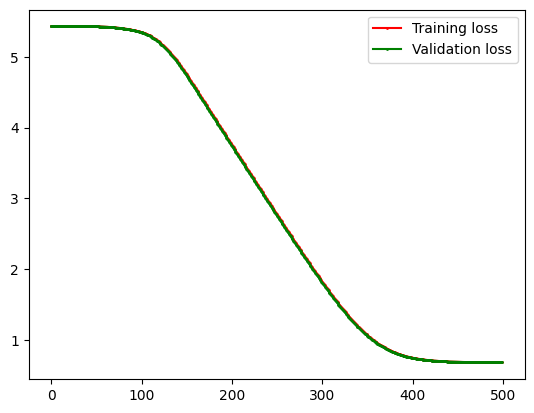

50. Training loss: 5.591997511584893, Val loss:5.591921347029843
100. Training loss: 5.518708066623792, Val loss:5.514159572680605
150. Training loss: 4.839010483564879, Val loss:4.818160850084141
200. Training loss: 3.7925457498022923, Val loss:3.771698590395527
250. Training loss: 2.7579204855236874, Val loss:2.737472107195564
300. Training loss: 1.7710902746313557, Val loss:1.752677233616366
350. Training loss: 1.0211206907651194, Val loss:1.0109536830610406
400. Training loss: 0.7435851244248235, Val loss:0.7415126902180931
450. Training loss: 0.6976695006864665, Val loss:0.6973789124347797
500. Training loss: 0.6901510082514688, Val loss:0.6900723829443524


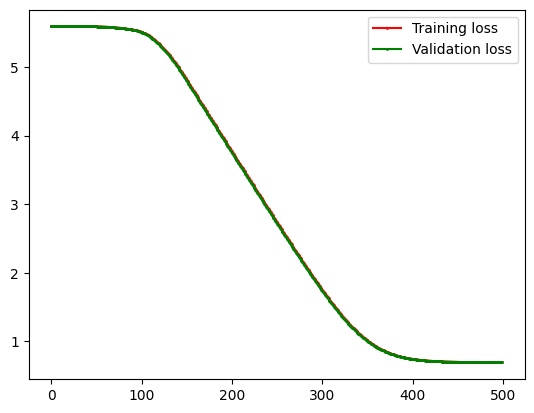

50. Training loss: 5.386409735425521, Val loss:5.386409735425521
100. Training loss: 5.315855511969166, Val loss:5.31167175063266
150. Training loss: 4.7481298746502345, Val loss:4.729744599025245
200. Training loss: 3.783889496430015, Val loss:3.764579982527372
250. Training loss: 2.8244655537937824, Val loss:2.8054546841362153
300. Training loss: 1.8968775504939783, Val loss:1.8791572533509622
350. Training loss: 1.12501036159978, Val loss:1.1131292696761659
400. Training loss: 0.7595309037060387, Val loss:0.756296548172499
450. Training loss: 0.6853109336708286, Val loss:0.684843330639317
500. Training loss: 0.6743317247998643, Val loss:0.6742410295017975


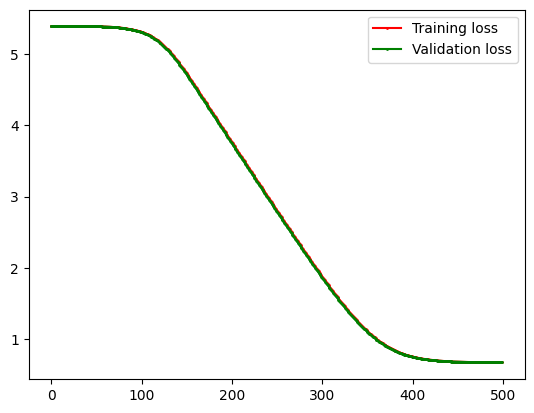

lr=0.005, λ=4.0 → avg accuracy=0.5543
50. Training loss: 5.509596025779808, Val loss:5.509461211538829
100. Training loss: 5.422461282325231, Val loss:5.415631117923728
150. Training loss: 4.669908045070467, Val loss:4.648945823811524
200. Training loss: 3.621186547543855, Val loss:3.600378140264626
250. Training loss: 2.5931660966531784, Val loss:2.572968149154728
300. Training loss: 1.630100435025033, Val loss:1.6125097046230394
350. Training loss: 0.9436724917623163, Val loss:0.9350183365618264
400. Training loss: 0.7184145730864965, Val loss:0.7168360610196538
450. Training loss: 0.6839164622408477, Val loss:0.6837003953277287
500. Training loss: 0.6782481506062599, Val loss:0.6781869031541935


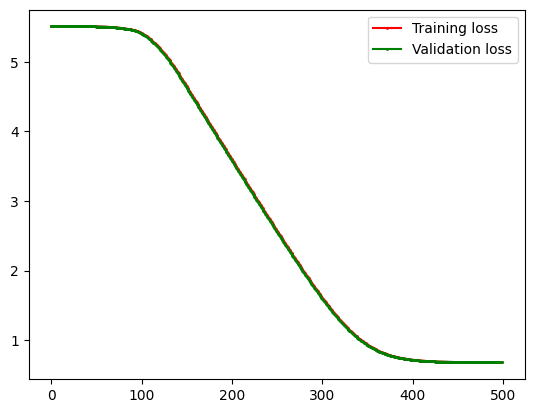

50. Training loss: 5.386401448073972, Val loss:5.386269837071897
100. Training loss: 5.2906498693154385, Val loss:5.285331886589256
150. Training loss: 4.606706563542889, Val loss:4.586999557951353
200. Training loss: 3.612902170107694, Val loss:3.593155058948173
250. Training loss: 2.636490390804484, Val loss:2.617268665109605
300. Training loss: 1.7118261429396862, Val loss:1.6946055938916897
350. Training loss: 1.00460723184982, Val loss:0.9947938410308768
400. Training loss: 0.7290461709077217, Val loss:0.7268928980461558
450. Training loss: 0.6808913480658357, Val loss:0.6805887897310351
500. Training loss: 0.6733666995308545, Val loss:0.6732944826375502


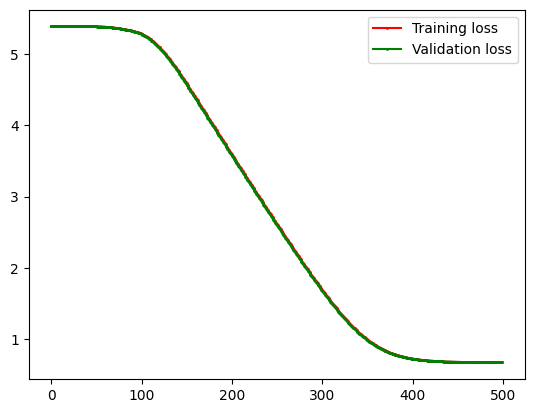

50. Training loss: 5.427421216673656, Val loss:5.427287624281399
100. Training loss: 5.333456995246089, Val loss:5.327738982795687
150. Training loss: 4.6428831610515156, Val loss:4.622573759252613
200. Training loss: 3.6182549833411666, Val loss:3.5979124372610016
250. Training loss: 2.6128353309666963, Val loss:2.59306266625621
300. Training loss: 1.6661147619677439, Val loss:1.6486653125181343
350. Training loss: 0.969598004956876, Val loss:0.9604432307958819
400. Training loss: 0.7241703621522991, Val loss:0.7223810842639296
450. Training loss: 0.68491921132601, Val loss:0.6846768408779379
500. Training loss: 0.6787812323872918, Val loss:0.6787193023741882


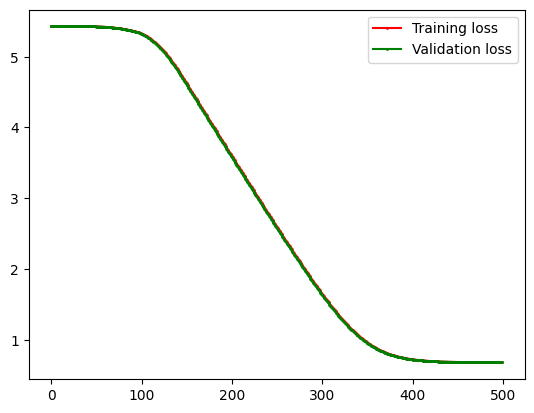

50. Training loss: 5.591743178084754, Val loss:5.591606581615366
100. Training loss: 5.493924713192928, Val loss:5.487172215779796
150. Training loss: 4.706022413995779, Val loss:4.684343340742524
200. Training loss: 3.6303161900037675, Val loss:3.6089876351146812
250. Training loss: 2.5772801016221485, Val loss:2.556620397493409
300. Training loss: 1.5979788398327315, Val loss:1.5803136400767537
350. Training loss: 0.9277701731205301, Val loss:0.9197288766872816
400. Training loss: 0.724453781045275, Val loss:0.7230754080621044
450. Training loss: 0.694081904184638, Val loss:0.6938812690529831
500. Training loss: 0.6884117014915111, Val loss:0.6883426482059529


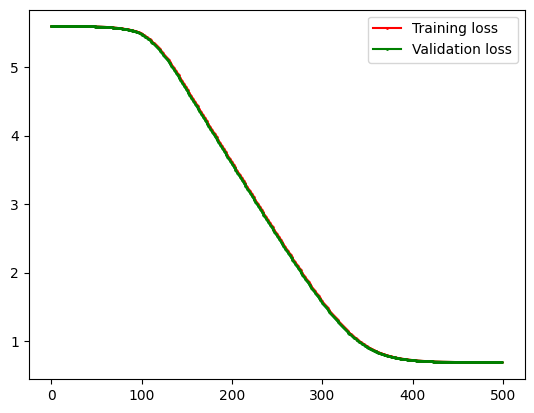

50. Training loss: 5.386409735425521, Val loss:5.386409735425521
100. Training loss: 5.293788062646255, Val loss:5.287917432530933
150. Training loss: 4.622847674984646, Val loss:4.602916780521608
200. Training loss: 3.6260972748827465, Val loss:3.6063023885330696
250. Training loss: 2.6471803903657025, Val loss:2.6279040625408436
300. Training loss: 1.7191724923561515, Val loss:1.7018664481802765
350. Training loss: 1.0069706916521097, Val loss:0.997063884584819
400. Training loss: 0.7289245556952003, Val loss:0.726760594903936
450. Training loss: 0.6807577379152603, Val loss:0.6804584560878918
500. Training loss: 0.673364490822928, Val loss:0.6732942123586394


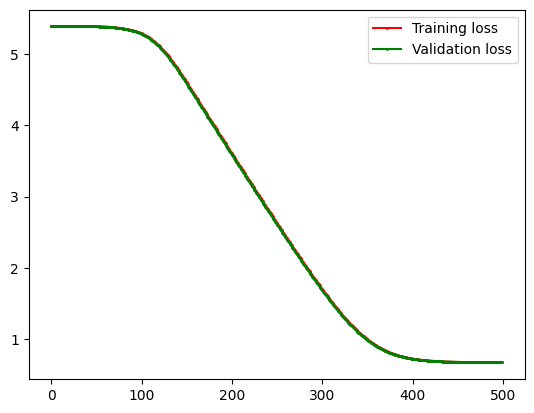

lr=0.005, λ=8.0 → avg accuracy=0.5543
50. Training loss: 5.4616356045109535, Val loss:5.4558259650255145
100. Training loss: 3.9253532311005617, Val loss:3.885484845938707
150. Training loss: 1.9644827051473288, Val loss:1.927379493028269
200. Training loss: 0.7664484245021814, Val loss:0.7598991503764498
250. Training loss: 0.680315368966681, Val loss:0.68013979847944
300. Training loss: 0.6749223801602551, Val loss:0.6748345285203059
350. Training loss: 0.6706332165789989, Val loss:0.6705490544078336
400. Training loss: 0.6664926543477087, Val loss:0.6664112260482234
450. Training loss: 0.6624858605140894, Val loss:0.6624070519667108
500. Training loss: 0.6586075159510033, Val loss:0.6585312242432655


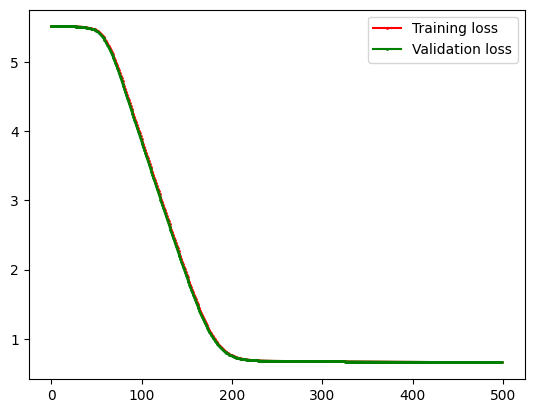

50. Training loss: 5.324664947955581, Val loss:5.319016926148049
100. Training loss: 3.9102687652521912, Val loss:3.8725256902528056
150. Training loss: 2.0482525400436775, Val loss:2.012571196317478
200. Training loss: 0.7959949768678127, Val loss:0.787300138429116
250. Training loss: 0.6753630720937926, Val loss:0.6751304007879195
300. Training loss: 0.6691286517045244, Val loss:0.6690358681421561
350. Training loss: 0.6646244409153982, Val loss:0.6645362632364525
400. Training loss: 0.6602901245275877, Val loss:0.6602049602413168
450. Training loss: 0.6561028556534897, Val loss:0.6560205662214581
500. Training loss: 0.6520563626543648, Val loss:0.6519768278397627


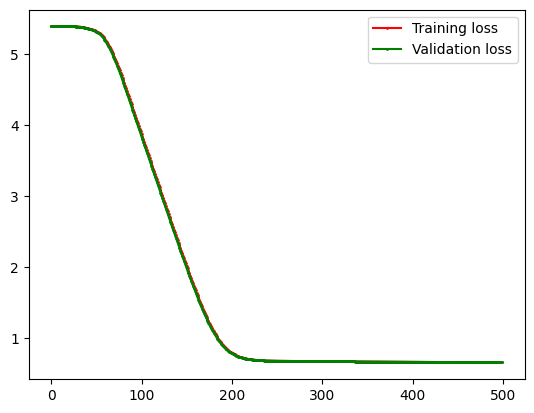

50. Training loss: 5.366548573629277, Val loss:5.360520639390412
100. Training loss: 3.919474067761609, Val loss:3.880539384183328
150. Training loss: 2.0017363433709656, Val loss:1.9652319250223151
200. Training loss: 0.7796919003608416, Val loss:0.7723125092878838
250. Training loss: 0.6812106524155034, Val loss:0.6810240871018483
300. Training loss: 0.6759243443124583, Val loss:0.6758423508283731
350. Training loss: 0.6719345224241647, Val loss:0.6718563718133722
400. Training loss: 0.6680937329359286, Val loss:0.6680182803510035
450. Training loss: 0.6643845802604146, Val loss:0.6643116989236644
500. Training loss: 0.6608012044860965, Val loss:0.6607307816094975


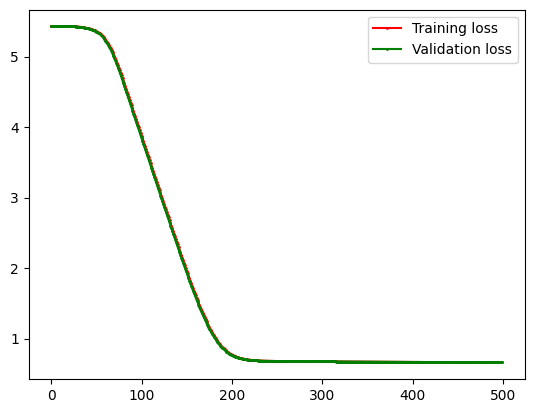

50. Training loss: 5.534876385189226, Val loss:5.528301309996282
100. Training loss: 3.9380532024714356, Val loss:3.897143562926554
150. Training loss: 1.9303998454453026, Val loss:1.8927397907423125
200. Training loss: 0.7664200749091614, Val loss:0.7607220771875888
250. Training loss: 0.6917611832571849, Val loss:0.6915837349488827
300. Training loss: 0.685721111567798, Val loss:0.6856175579803715
350. Training loss: 0.6806623991427114, Val loss:0.6805632493559902
400. Training loss: 0.6757924912404025, Val loss:0.6756968858189849
450. Training loss: 0.6710957878355515, Val loss:0.6710035678870724
500. Training loss: 0.6665647414275455, Val loss:0.6664757604020398


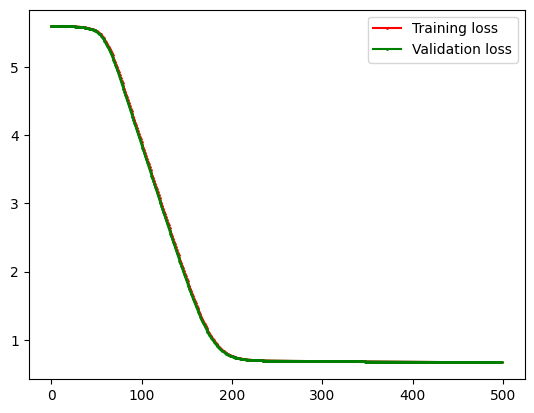

50. Training loss: 5.330868101513116, Val loss:5.324862106023688
100. Training loss: 3.9244125445256253, Val loss:3.886581746530999
150. Training loss: 2.0573744807077374, Val loss:2.0215573095991286
200. Training loss: 0.7965303768315349, Val loss:0.7877563188225211
250. Training loss: 0.6754233712062694, Val loss:0.6751962576927498
300. Training loss: 0.6693995421449147, Val loss:0.6693104143926116
350. Training loss: 0.6650772981670893, Val loss:0.6649927771191628
400. Training loss: 0.6609272430145083, Val loss:0.6608457930241542
450. Training loss: 0.6569269741237344, Val loss:0.6568484502218364
500. Training loss: 0.6530698707983403, Val loss:0.652994145818115


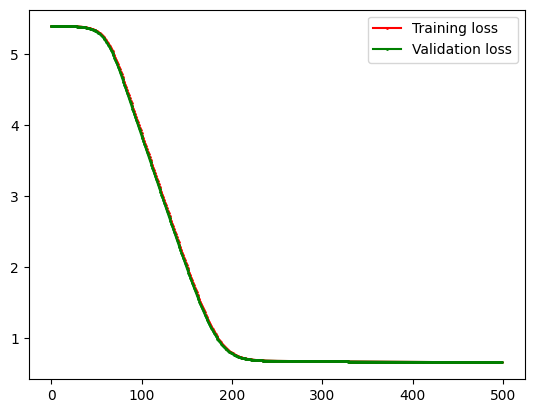

lr=0.01, λ=1.0 → avg accuracy=0.5943
50. Training loss: 5.458436569496158, Val loss:5.451585468166604
100. Training loss: 3.883821994275092, Val loss:3.8436833750310337
150. Training loss: 1.9161114713753322, Val loss:1.8791640394443294
200. Training loss: 0.7570438344336686, Val loss:0.7511357288505793
250. Training loss: 0.6799408747718528, Val loss:0.6797766546075508
300. Training loss: 0.6746863414652263, Val loss:0.674598894860389
350. Training loss: 0.6704190929005263, Val loss:0.6703354789236945
400. Training loss: 0.6663123289290211, Val loss:0.6662317073174441
450. Training loss: 0.662351843043426, Val loss:0.6622740816418505
500. Training loss: 0.6585313521094496, Val loss:0.6584563287034018


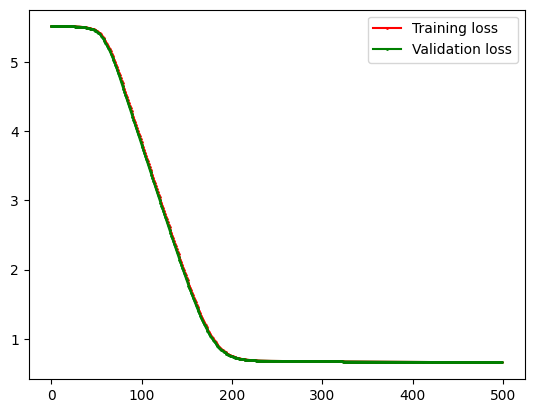

50. Training loss: 5.321265382007614, Val loss:5.315347849609483
100. Training loss: 3.8695860888703075, Val loss:3.831573080475992
150. Training loss: 1.9998058527268192, Val loss:1.9642028506088394
200. Training loss: 0.7830573091547421, Val loss:0.7751613993129358
250. Training loss: 0.6749713328099377, Val loss:0.6747576955915683
300. Training loss: 0.6689813055733759, Val loss:0.6688893637177459
350. Training loss: 0.664516851718011, Val loss:0.6644295547368579
400. Training loss: 0.6602328899223583, Val loss:0.6601488628317259
450. Training loss: 0.6561084243891123, Val loss:0.6560275111666545
500. Training loss: 0.6521361749651766, Val loss:0.6520582347042917


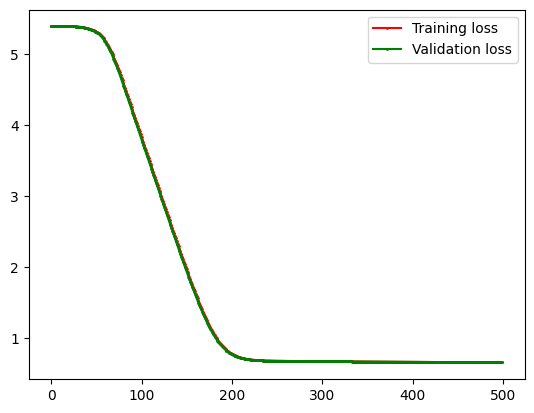

50. Training loss: 5.362962368810197, Val loss:5.356739412186375
100. Training loss: 3.878310027144638, Val loss:3.83910514437117
150. Training loss: 1.9532922853790726, Val loss:1.916907343375533
200. Training loss: 0.7688747778825028, Val loss:0.7622040051839328
250. Training loss: 0.6807701995684663, Val loss:0.6805972380902764
300. Training loss: 0.675639501363543, Val loss:0.6755576805136936
350. Training loss: 0.6716579732093902, Val loss:0.6715800755279117
400. Training loss: 0.6678354991671179, Val loss:0.6677605292475168
450. Training loss: 0.6641557967849, Val loss:0.6640836120503758
500. Training loss: 0.6606121298594343, Val loss:0.6605425997983296


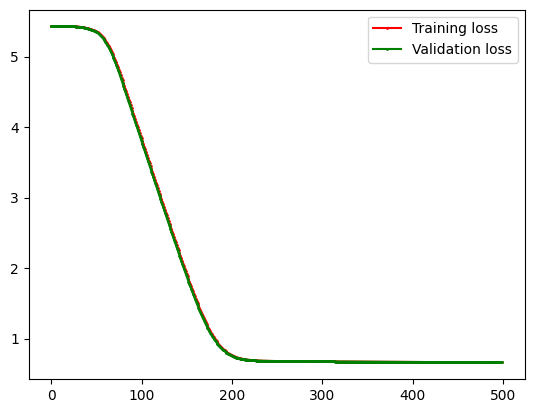

50. Training loss: 5.531117616503814, Val loss:5.524092217194119
100. Training loss: 3.8960707431098003, Val loss:3.854890579846137
150. Training loss: 1.8821610118912855, Val loss:1.844704757697575
200. Training loss: 0.7582399404881174, Val loss:0.7531047142653521
250. Training loss: 0.6912042166403797, Val loss:0.6910352948653166
300. Training loss: 0.6852457155137492, Val loss:0.6851419390449154
350. Training loss: 0.6801797946274734, Val loss:0.6800806413420172
400. Training loss: 0.675317186763826, Val loss:0.675221879402282
450. Training loss: 0.6706422884193297, Val loss:0.670550644001509
500. Training loss: 0.6661463214562481, Val loss:0.6660581692640766


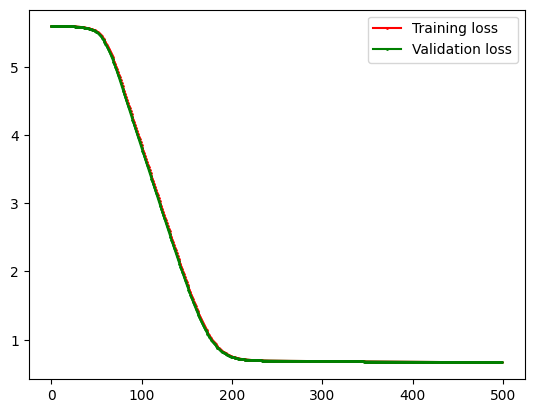

50. Training loss: 5.327243855053586, Val loss:5.320988722108261
100. Training loss: 3.8835984950518747, Val loss:3.845496631290816
150. Training loss: 2.008692436760195, Val loss:1.97294900363838
200. Training loss: 0.7834507590433584, Val loss:0.7754864419832246
250. Training loss: 0.6750221928998901, Val loss:0.6748138508175681
300. Training loss: 0.6692322332271223, Val loss:0.6691437677636884
350. Training loss: 0.6649403839796768, Val loss:0.6648565445185826
400. Training loss: 0.6608300902493199, Val loss:0.6607495524154742
450. Training loss: 0.6568807559517184, Val loss:0.6568033582315012
500. Training loss: 0.6530848050147491, Val loss:0.653010400674651


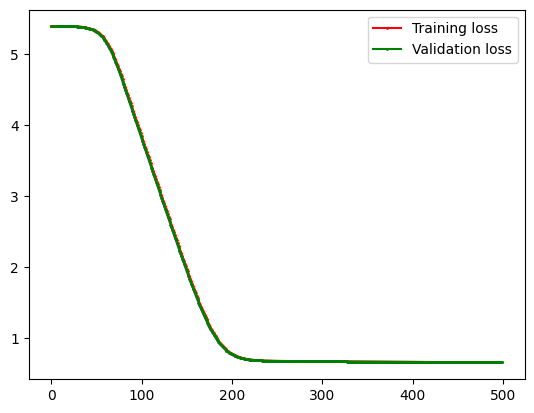

lr=0.01, λ=2.0 → avg accuracy=0.5971
50. Training loss: 5.450344604309193, Val loss:5.4420152822219405
100. Training loss: 3.8017348444539607, Val loss:3.7610743606745585
150. Training loss: 1.8222569920481424, Val loss:1.7857163054953553
200. Training loss: 0.7412570033521952, Val loss:0.7364568657621829
250. Training loss: 0.6792862236359607, Val loss:0.6791404039442708
300. Training loss: 0.6742681476904956, Val loss:0.6741817353088658
350. Training loss: 0.6700586208494577, Val loss:0.6699764019498349
400. Training loss: 0.6660346383090052, Val loss:0.6659559372686151
450. Training loss: 0.6621821833806574, Val loss:0.6621068247565409
500. Training loss: 0.6584927482556193, Val loss:0.6584205660373263


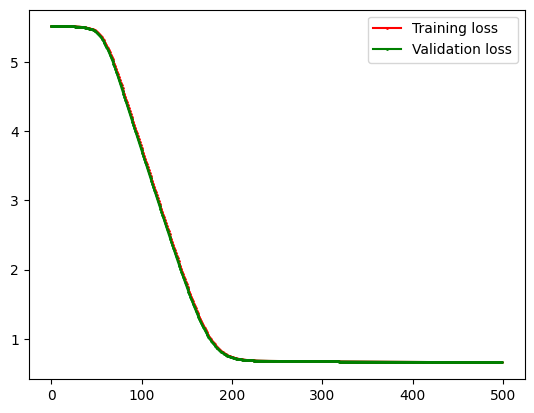

50. Training loss: 5.314064001492158, Val loss:5.306725723681081
100. Training loss: 3.789171644209681, Val loss:3.750636846010809
150. Training loss: 1.9055608701441502, Val loss:1.8701943304441382
200. Training loss: 0.7611773458417195, Val loss:0.75469236961558
250. Training loss: 0.6743159833570758, Val loss:0.6741329874852406
300. Training loss: 0.6687336252148053, Val loss:0.6686434913349656
350. Training loss: 0.6643592372800071, Val loss:0.6642739413504196
400. Training loss: 0.6601880831691872, Val loss:0.6601065726792303
450. Training loss: 0.6562012283644354, Val loss:0.6561233045236304
500. Training loss: 0.6523890878854702, Val loss:0.652314563740174


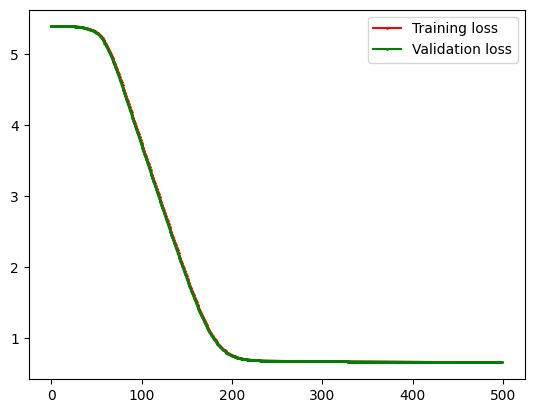

50. Training loss: 5.355564374010386, Val loss:5.3484540496933715
100. Training loss: 3.7969465263402835, Val loss:3.7572196073963653
150. Training loss: 1.8591810364246328, Val loss:1.8231233201209565
200. Training loss: 0.7506651081479498, Val loss:0.7452287462089734
250. Training loss: 0.6799998542572162, Val loss:0.6798487600919114
300. Training loss: 0.6751285030045306, Val loss:0.675047272086357
350. Training loss: 0.6711792823113488, Val loss:0.6711022339512116
400. Training loss: 0.6674110980094395, Val loss:0.6673374548869081
450. Training loss: 0.6638086569676285, Val loss:0.663738237722143
500. Training loss: 0.6603631859449284, Val loss:0.6602958197307495


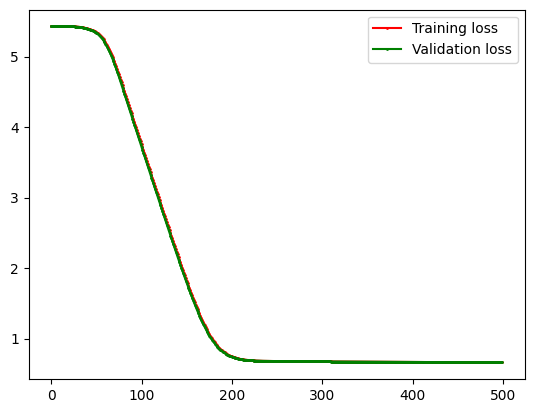

50. Training loss: 5.522947531643687, Val loss:5.514127051614299
100. Training loss: 3.8130944166063125, Val loss:3.7713921325139244
150. Training loss: 1.7887144336354304, Val loss:1.7517689985428238
200. Training loss: 0.7444784823280511, Val loss:0.7403088467370604
250. Training loss: 0.690183575089232, Val loss:0.6900284084222195
300. Training loss: 0.684362887130444, Val loss:0.6842589871103844
350. Training loss: 0.6793010865408581, Val loss:0.6792023194310535
400. Training loss: 0.6744731883512743, Val loss:0.6743788870136422
450. Training loss: 0.6698626482259363, Val loss:0.6697725740585412
500. Training loss: 0.6654579117732499, Val loss:0.6653718401474524


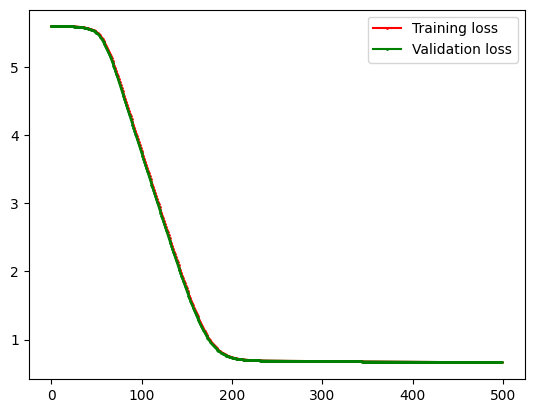

50. Training loss: 5.319623946806911, Val loss:5.311640620012464
100. Training loss: 3.8029238811497503, Val loss:3.7642979875603033
150. Training loss: 1.9139713360220392, Val loss:1.8784548133788523
200. Training loss: 0.7613432289252228, Val loss:0.7548088609659865
250. Training loss: 0.6743483078041335, Val loss:0.6741700940940647
300. Training loss: 0.6689463672563927, Val loss:0.6688593755230847
350. Training loss: 0.664727175139486, Val loss:0.6646449679786824
400. Training loss: 0.66071016757968, Val loss:0.6606317336802561
450. Training loss: 0.6568767843610734, Val loss:0.6568019219217951
500. Training loss: 0.6532172762552438, Val loss:0.6531457951441507


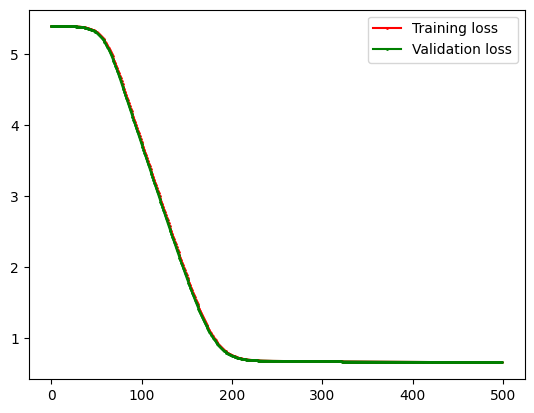

lr=0.01, λ=4.0 → avg accuracy=0.6029
50. Training loss: 5.428964938794786, Val loss:5.415533049145779
100. Training loss: 3.6414039206096835, Val loss:3.599772990521368
150. Training loss: 1.646460715443193, Val loss:1.6111385510757181
200. Training loss: 0.7189567549601086, Val loss:0.7157914493414745
250. Training loss: 0.6782734850499649, Val loss:0.6781526229185181
300. Training loss: 0.6736241741666533, Val loss:0.6735406054647647
350. Training loss: 0.6695753389545971, Val loss:0.6694968522714475
400. Training loss: 0.6657635748790138, Val loss:0.6656896324516883
450. Training loss: 0.6621718565499272, Val loss:0.6621021680988797
500. Training loss: 0.658786037140435, Val loss:0.6587203282352831


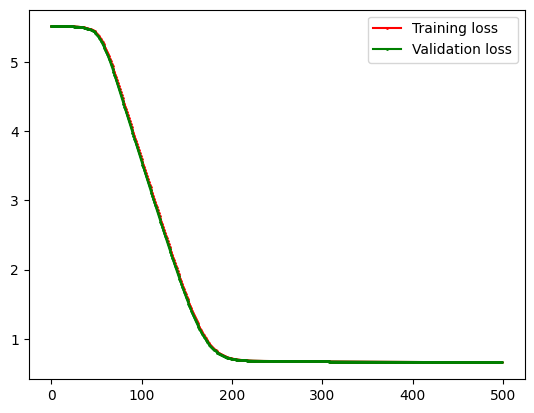

50. Training loss: 5.295501856459262, Val loss:5.28524998694277
100. Training loss: 3.6320891595385745, Val loss:3.592581883022972
150. Training loss: 1.727947023241895, Val loss:1.6933975705768343
200. Training loss: 0.7299786034264774, Val loss:0.7256461726325857
250. Training loss: 0.6733885179999435, Val loss:0.6732463244459189
300. Training loss: 0.6684043966462346, Val loss:0.6683183411716785
350. Training loss: 0.6642440681951985, Val loss:0.6641635093611287
400. Training loss: 0.660334421184862, Val loss:0.6602586365373112
450. Training loss: 0.6566557675020117, Val loss:0.656584444068742
500. Training loss: 0.6531928044339944, Val loss:0.6531256447580976


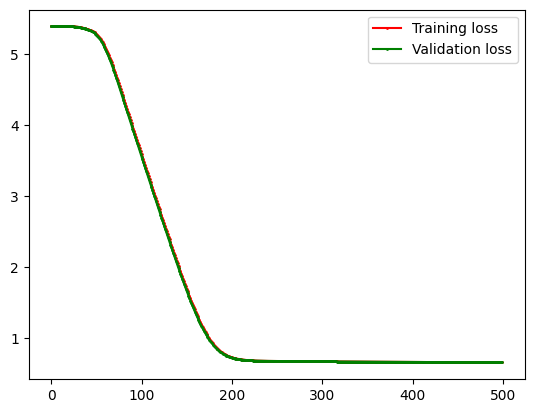

50. Training loss: 5.338419450372068, Val loss:5.3276554917007966
100. Training loss: 3.6380201397225522, Val loss:3.5973214240126503
150. Training loss: 1.6823938248503734, Val loss:1.6473689893582124
200. Training loss: 0.7248489111051413, Val loss:0.7212556726798444
250. Training loss: 0.6788026300877453, Val loss:0.6786806127512783
300. Training loss: 0.6743163732832865, Val loss:0.6742371856136669
350. Training loss: 0.670483698944548, Val loss:0.6704094496781177
400. Training loss: 0.6668794292782928, Val loss:0.666809546291959
450. Training loss: 0.6634863811587005, Val loss:0.6634205769290978
500. Training loss: 0.6602905274560886, Val loss:0.6602285299617079


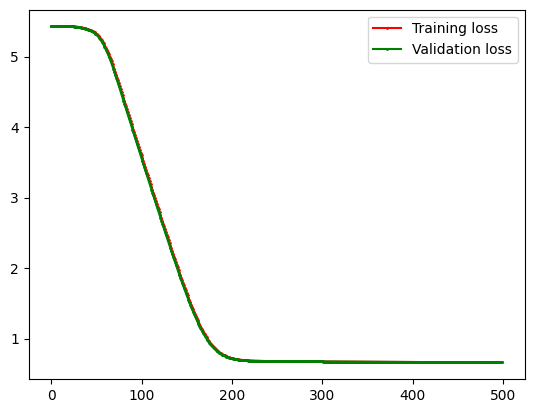

50. Training loss: 5.500352706806324, Val loss:5.48707108220106
100. Training loss: 3.65103809278356, Val loss:3.608366204052538
150. Training loss: 1.6143357704445702, Val loss:1.578845801193726
200. Training loss: 0.7248778500122376, Val loss:0.7221186735562514
250. Training loss: 0.6884478145494659, Val loss:0.6883111329450272
300. Training loss: 0.6828438336577534, Val loss:0.6827408146797455
350. Training loss: 0.6778526305192496, Val loss:0.6777559270671608
400. Training loss: 0.6731589190239733, Val loss:0.6730679228518566
450. Training loss: 0.6687411637727044, Val loss:0.6686554949462332
500. Training loss: 0.6645809628265411, Val loss:0.6645002660031026


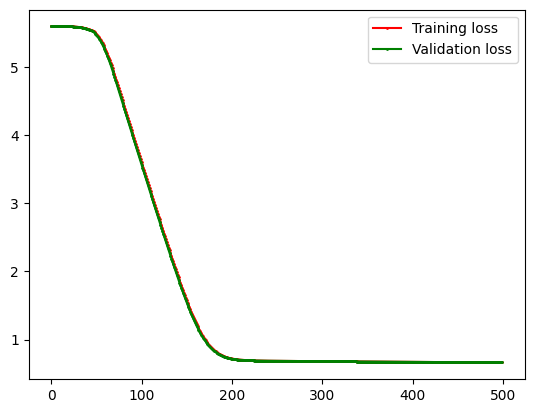

50. Training loss: 5.299126783533546, Val loss:5.287829140441709
100. Training loss: 3.6453309888726193, Val loss:3.6057282131339554
150. Training loss: 1.7353828984130306, Val loss:1.7006635998782378
200. Training loss: 0.729862523424938, Val loss:0.7255082886461169
250. Training loss: 0.6733850488063856, Val loss:0.673246711295444
300. Training loss: 0.668547403413177, Val loss:0.668463910101638
350. Training loss: 0.6645122091654685, Val loss:0.664434107715244
400. Training loss: 0.6607236109872058, Val loss:0.6606502101261716
450. Training loss: 0.6571624098941129, Val loss:0.6570933998442723
500. Training loss: 0.6538134484389997, Val loss:0.6537485345517492


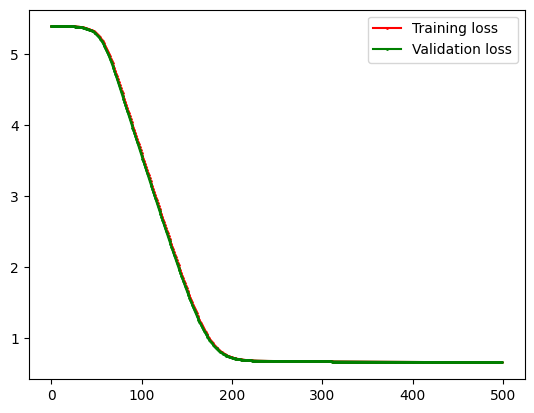

lr=0.01, λ=8.0 → avg accuracy=0.6029
50. Training loss: 0.6592341419617492, Val loss:0.6584682205967101
100. Training loss: 0.6262916823319536, Val loss:0.6257304884989499
150. Training loss: 0.6018508508081452, Val loss:0.6014284745859549
200. Training loss: 0.5832331151294474, Val loss:0.5829070765973009
250. Training loss: 0.5687061970023032, Val loss:0.5684488226447827
300. Training loss: 0.5571308646232414, Val loss:0.5569237260769765
350. Training loss: 0.5477396603487811, Val loss:0.5475701687210237
400. Training loss: 0.5400020947578408, Val loss:0.5398614282205502
450. Training loss: 0.5335422288301445, Val loss:0.5334240554766407
500. Training loss: 0.5280874313613461, Val loss:0.5279871058540495


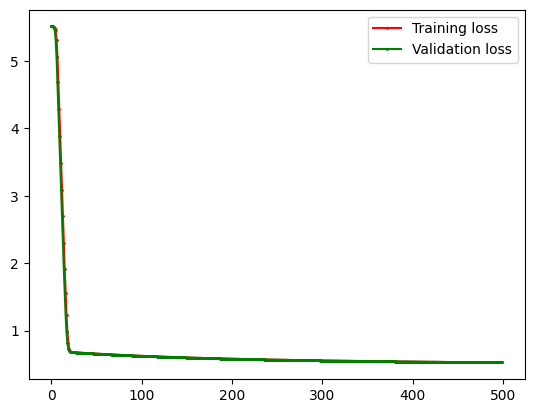

50. Training loss: 0.6527077347897164, Val loss:0.6519091349855968
100. Training loss: 0.6185830584806787, Val loss:0.6180055328012048
150. Training loss: 0.5935316718210151, Val loss:0.5931003341326413
200. Training loss: 0.5745524685985817, Val loss:0.5742205243507943
250. Training loss: 0.5597626320519056, Val loss:0.5595004645407495
300. Training loss: 0.5479568252670055, Val loss:0.5477451846157676
350. Training loss: 0.5383407100367076, Val loss:0.53816669615136
400. Training loss: 0.5303745104397819, Val loss:0.5302292144688902
450. Training loss: 0.5236805688992394, Val loss:0.5235576648764108
500. Training loss: 0.5179875370695993, Val loss:0.5178824193845866


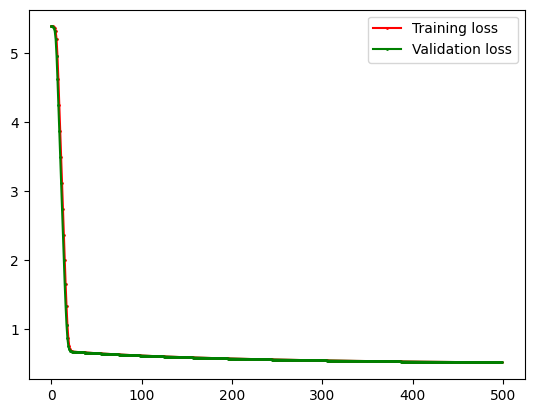

50. Training loss: 0.6613725526345149, Val loss:0.6606654967483089
100. Training loss: 0.6311698757373514, Val loss:0.6306585216048847
150. Training loss: 0.608959800139203, Val loss:0.6085766737125796
200. Training loss: 0.5920674500333155, Val loss:0.5917712769602497
250. Training loss: 0.5788407637433484, Val loss:0.5786056848012673
300. Training loss: 0.5682298213679589, Val loss:0.5680391043868506
350. Training loss: 0.5595447580824354, Val loss:0.5593872060429604
400. Training loss: 0.5523170046365741, Val loss:0.5521848805717463
450. Training loss: 0.5462183132583472, Val loss:0.5461061123492758
500. Training loss: 0.5410122354961493, Val loss:0.5409159374360856


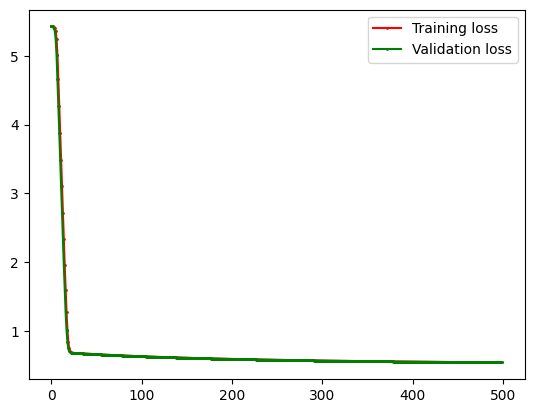

50. Training loss: 0.6672925256970866, Val loss:0.6663989086615415
100. Training loss: 0.6294006947593992, Val loss:0.6287649505070332
150. Training loss: 0.6020139721652944, Val loss:0.6015459949384925
200. Training loss: 0.5815467149418007, Val loss:0.5811910851632944
250. Training loss: 0.5657845819782764, Val loss:0.5655067521496707
300. Training loss: 0.5533303549325591, Val loss:0.5531081728102148
350. Training loss: 0.5432751451091851, Val loss:0.543093948059334
400. Training loss: 0.5350087032438631, Val loss:0.5348584813855095
450. Training loss: 0.5281088334664249, Val loss:0.5279825554378031
500. Training loss: 0.5222753454713575, Val loss:0.5221679430457413


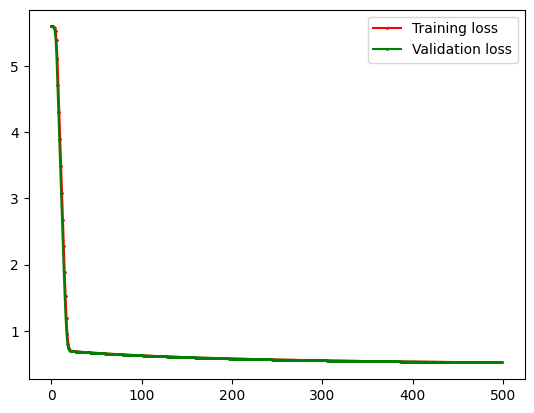

50. Training loss: 0.6536821159451061, Val loss:0.6529216238160295
100. Training loss: 0.6215223933572706, Val loss:0.6209846715129395
150. Training loss: 0.5984378807387479, Val loss:0.5980450754241691
200. Training loss: 0.5813261251181221, Val loss:0.5810301657068542
250. Training loss: 0.5682622948929353, Val loss:0.5680330836857662
300. Training loss: 0.5580279895233391, Val loss:0.5578461990232626
350. Training loss: 0.5498306251295457, Val loss:0.5496834834493811
400. Training loss: 0.5431395515382998, Val loss:0.5430183752928457
450. Training loss: 0.5375894603244575, Val loss:0.5374881853568649
500. Training loss: 0.5329222641378497, Val loss:0.5328365495637926


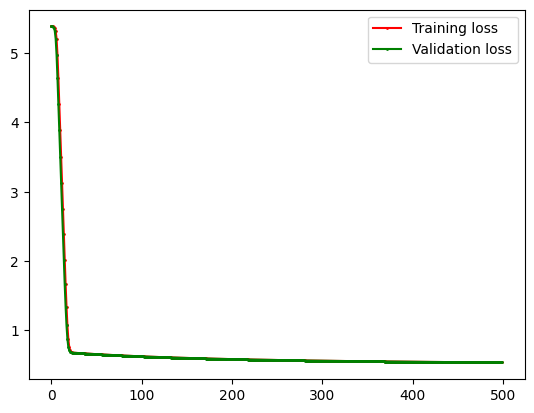

lr=0.1, λ=1.0 → avg accuracy=0.7200
50. Training loss: 0.6591356582847974, Val loss:0.6583821233142986
100. Training loss: 0.6272150792741945, Val loss:0.6266805312520562
150. Training loss: 0.6042606294194232, Val loss:0.6038701976138882
200. Training loss: 0.5872816009175762, Val loss:0.5869887580718959
250. Training loss: 0.5744059825463781, Val loss:0.5741812650732496
300. Training loss: 0.5644335279962294, Val loss:0.5642577446185687
350. Training loss: 0.5565716658291828, Val loss:0.5564319351598759
400. Training loss: 0.5502812812123962, Val loss:0.5501687054809127
450. Training loss: 0.545185382420147, Val loss:0.5450936525065828
500. Training loss: 0.5410136882173749, Val loss:0.5409382246604769


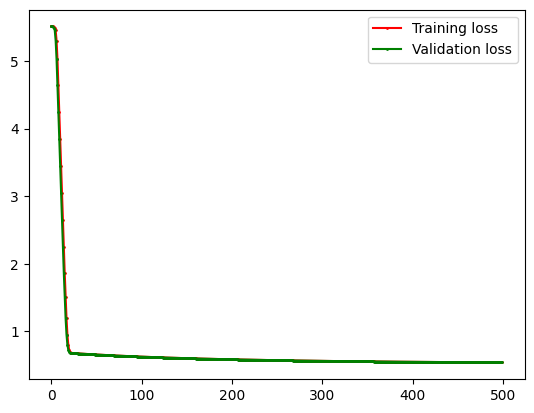

50. Training loss: 0.6527620185129143, Val loss:0.6519790737448956
100. Training loss: 0.619807684113408, Val loss:0.6192593800077859
150. Training loss: 0.5963522373468968, Val loss:0.5959546752719774
200. Training loss: 0.5790909561946551, Val loss:0.5787935869872064
250. Training loss: 0.5660158891021784, Val loss:0.5657875703004381
300. Training loss: 0.5558715914135473, Val loss:0.5556924799370486
350. Training loss: 0.5478450785096204, Val loss:0.5477020738456243
400. Training loss: 0.5413912122879071, Val loss:0.5412753712023177
450. Training loss: 0.5361325596889702, Val loss:0.536037590708095
500. Training loss: 0.5318002589157709, Val loss:0.531721617433893


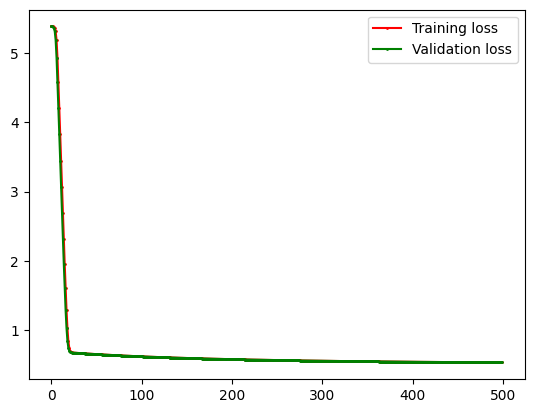

50. Training loss: 0.6611654281387842, Val loss:0.6604670373233883
100. Training loss: 0.6317512181501528, Val loss:0.6312611117529686
150. Training loss: 0.610743243936684, Val loss:0.6103862433934806
200. Training loss: 0.5952039823050922, Val loss:0.5949354856320405
250. Training loss: 0.5833671170926995, Val loss:0.5831597983414839
300. Training loss: 0.574131759948295, Val loss:0.5739682218673187
350. Training loss: 0.5667847057235562, Val loss:0.5666534436786678
400. Training loss: 0.5608466013758086, Val loss:0.5607397377904612
450. Training loss: 0.5559844169935317, Val loss:0.5558963888089884
500. Training loss: 0.5519599562852889, Val loss:0.5518867279661107


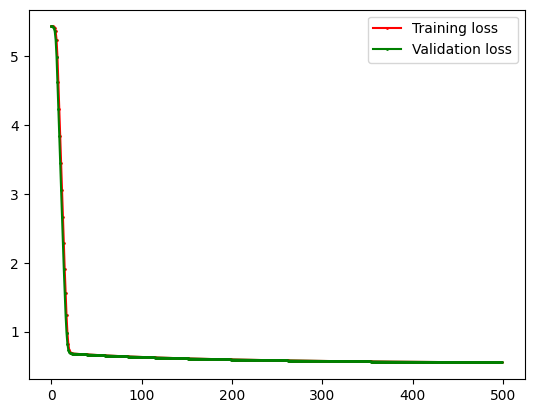

50. Training loss: 0.6668537463960051, Val loss:0.6659680825334183
100. Training loss: 0.6298105721397144, Val loss:0.6291986134758378
150. Training loss: 0.6037768280570314, Val loss:0.6033382517056612
200. Training loss: 0.5848249725091603, Val loss:0.5845001597191521
250. Training loss: 0.5706008260696096, Val loss:0.5703535204307429
300. Training loss: 0.5596505987721845, Val loss:0.559457966056362
350. Training loss: 0.5510433311407661, Val loss:0.5508904551804905
400. Training loss: 0.5441611445187822, Val loss:0.5440379416306094
450. Training loss: 0.5385802537827172, Val loss:0.5384796933668388
500. Training loss: 0.5340013531958284, Val loss:0.5339183975899638


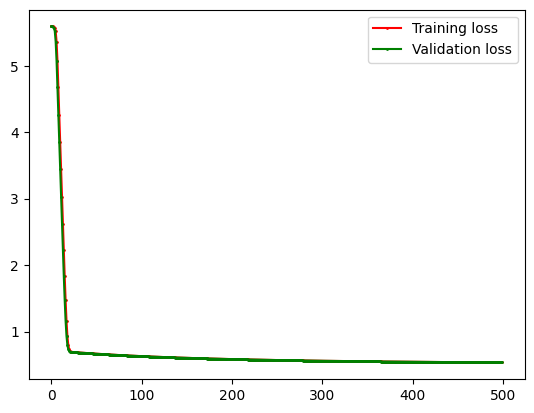

50. Training loss: 0.6536746113955451, Val loss:0.6529270691332852
100. Training loss: 0.6225005994418218, Val loss:0.6219875381985634
150. Training loss: 0.6007546578789569, Val loss:0.6003899719146721
200. Training loss: 0.5850613974674714, Val loss:0.5847937440148215
250. Training loss: 0.5733905631448065, Val loss:0.5731886358119189
300. Training loss: 0.5644867898503332, Val loss:0.5643308815286184
350. Training loss: 0.5575476732294545, Val loss:0.5574249536546922
400. Training loss: 0.5520429752937784, Val loss:0.551944817447031
450. Training loss: 0.5476112047590044, Val loss:0.5475316333734879
500. Training loss: 0.5439988284358939, Val loss:0.5439335930851117


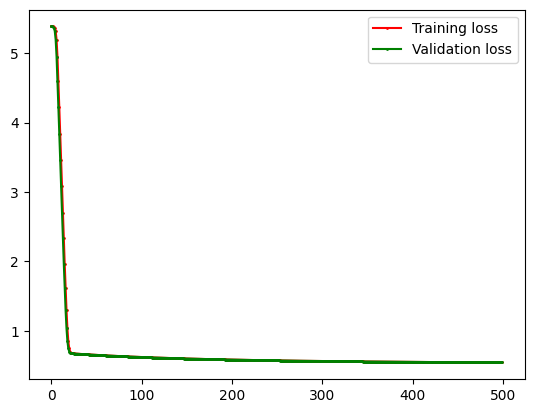

lr=0.1, λ=2.0 → avg accuracy=0.7314
50. Training loss: 0.6590510991586813, Val loss:0.6583254569565009
100. Training loss: 0.6292909302817304, Val loss:0.6288108260893926
150. Training loss: 0.6092967357980593, Val loss:0.6089684730356453
200. Training loss: 0.5954421850440108, Val loss:0.5952113421634824
250. Training loss: 0.5855917715108557, Val loss:0.5854256791316356
300. Training loss: 0.5784414533517784, Val loss:0.5783197377124346
350. Training loss: 0.573164283012725, Val loss:0.5730737685820206
400. Training loss: 0.5692174004206483, Val loss:0.5691492886092303
450. Training loss: 0.5662335587019737, Val loss:0.5661818101017728
500. Training loss: 0.5639578943110899, Val loss:0.5639182663431539


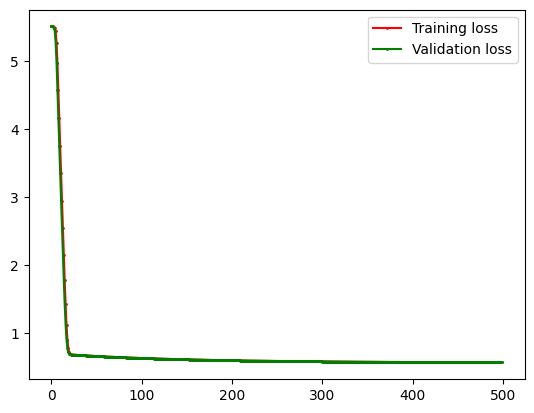

50. Training loss: 0.6529634939116556, Val loss:0.6522142117065476
100. Training loss: 0.6224183000770527, Val loss:0.6219285122513624
150. Training loss: 0.6020888323011251, Val loss:0.6017560808191468
200. Training loss: 0.5880630354590528, Val loss:0.5878295503079323
250. Training loss: 0.5780990155239629, Val loss:0.5779309242160833
300. Training loss: 0.5708555465182191, Val loss:0.5707320746840048
350. Training loss: 0.5654939131234634, Val loss:0.5654017710190937
400. Training loss: 0.5614683074830761, Val loss:0.5613986764716243
450. Training loss: 0.5584112523416191, Val loss:0.558358098017207
500. Training loss: 0.5560682315251626, Val loss:0.5560273183098191


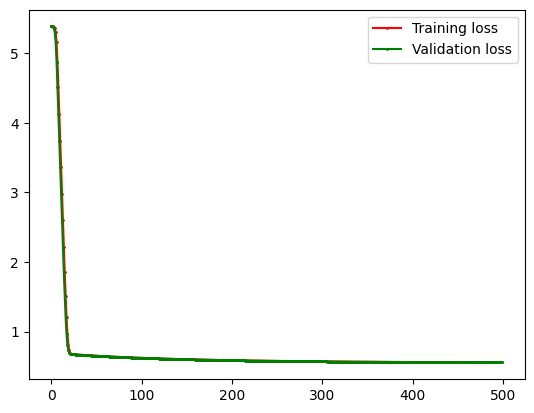

50. Training loss: 0.6608781166391334, Val loss:0.6602008941934401
100. Training loss: 0.6332184945355717, Val loss:0.6327737678651281
150. Training loss: 0.6147091164540953, Val loss:0.6144051447178411
200. Training loss: 0.6018588276978342, Val loss:0.6016441717788814
250. Training loss: 0.592670959522518, Val loss:0.5925154216912458
300. Training loss: 0.5859479960231748, Val loss:0.5858329898656366
350. Training loss: 0.5809381763775329, Val loss:0.5808517634054488
400. Training loss: 0.5771503017266869, Val loss:0.5770845289500746
450. Training loss: 0.5742524173534156, Val loss:0.5742018233918308
500. Training loss: 0.5720138303462748, Val loss:0.5719745695376564


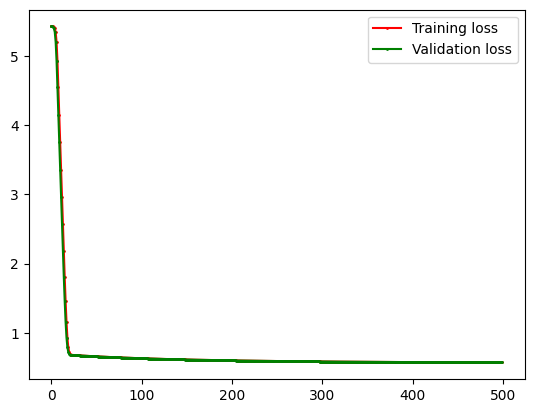

50. Training loss: 0.6661218971080786, Val loss:0.6652564354145937
100. Training loss: 0.6309686388684875, Val loss:0.6304072669646423
150. Training loss: 0.6077368534518445, Val loss:0.6073578257275176
200. Training loss: 0.5917973054787391, Val loss:0.591532616559144
250. Training loss: 0.5805212385858294, Val loss:0.580331357606219
300. Training loss: 0.5723489021944098, Val loss:0.5722097709210504
350. Training loss: 0.5663121004188262, Val loss:0.5662084344178184
400. Training loss: 0.5617848950258069, Val loss:0.5617066140237187
450. Training loss: 0.5583482912971448, Val loss:0.5582885344150871
500. Training loss: 0.5557135475229624, Val loss:0.5556675213448304


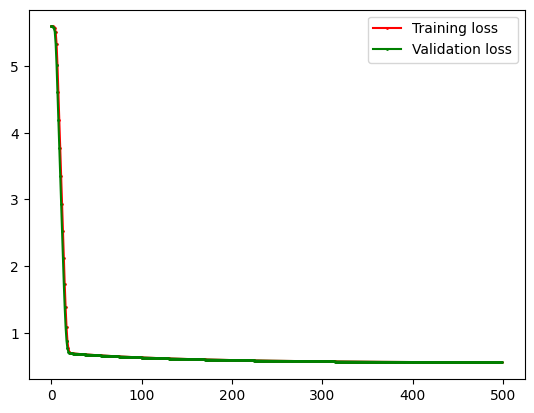

50. Training loss: 0.6537611190082774, Val loss:0.6530423621090348
100. Training loss: 0.6246775530040379, Val loss:0.6242154054465514
150. Training loss: 0.6056418025880371, Val loss:0.6053330449338987
200. Training loss: 0.5927254865280095, Val loss:0.5925123463486506
250. Training loss: 0.5836950782636706, Val loss:0.5835439829571641
300. Training loss: 0.5772277026802981, Val loss:0.5771182924974426
350. Training loss: 0.5725060949955371, Val loss:0.572425512780744
400. Training loss: 0.5690054900783889, Val loss:0.5689453208004034
450. Training loss: 0.5663774651788762, Val loss:0.5663320305156507
500. Training loss: 0.5643840488314488, Val loss:0.564349417994918


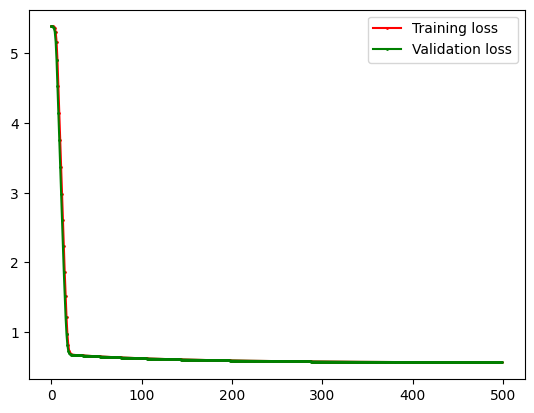

lr=0.1, λ=4.0 → avg accuracy=0.7371
50. Training loss: 0.6592517558717851, Val loss:0.6585901492021295
100. Training loss: 0.6339362934169039, Val loss:0.633560494630235
150. Training loss: 0.6192864823192532, Val loss:0.619064242210634
200. Training loss: 0.6104939022436, Val loss:0.6103582844304378
250. Training loss: 0.6050684428318782, Val loss:0.6049837251072218
300. Training loss: 0.6016512035547746, Val loss:0.6015973581684609
350. Training loss: 0.5994658733088478, Val loss:0.5994312062583831
400. Training loss: 0.598052373134224, Val loss:0.5980298356978061
450. Training loss: 0.5971301771130023, Val loss:0.5971154156629991
500. Training loss: 0.5965244890881166, Val loss:0.5965147642033528


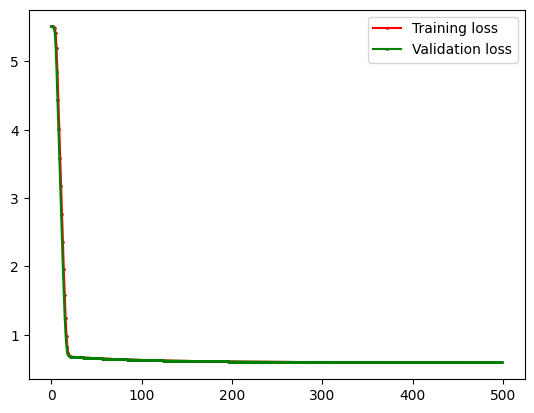

50. Training loss: 0.6536666324621667, Val loss:0.6529903555712916
100. Training loss: 0.6279168779484392, Val loss:0.6275365395796929
150. Training loss: 0.6131265012938124, Val loss:0.6129026503860503
200. Training loss: 0.6042790930921222, Val loss:0.6041427452628186
250. Training loss: 0.5988256607068609, Val loss:0.5987405121437614
300. Training loss: 0.5953903482158684, Val loss:0.5953361981826265
350. Training loss: 0.5931916071594222, Val loss:0.5931567041247523
400. Training loss: 0.5917674867082573, Val loss:0.5917447587878382
450. Training loss: 0.5908366315272213, Val loss:0.5908217134197864
500. Training loss: 0.5902237901285774, Val loss:0.5902139353553033


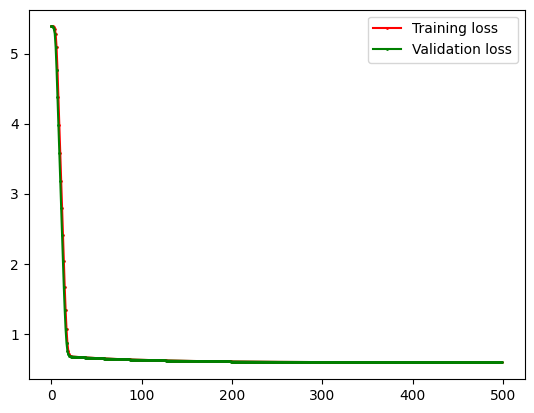

50. Training loss: 0.6607248310258927, Val loss:0.6601006431328579
100. Training loss: 0.6368928152858179, Val loss:0.6365395120412772
150. Training loss: 0.6231107331874959, Val loss:0.622901305729078
200. Training loss: 0.6148042095763608, Val loss:0.6146756158331252
250. Training loss: 0.6096395989050424, Val loss:0.6095585296566383
300. Training loss: 0.6063527532768853, Val loss:0.606300617622692
350. Training loss: 0.6042235610501488, Val loss:0.6041895152226836
400. Training loss: 0.6028251814764484, Val loss:0.602802679101283
450. Training loss: 0.601896676949605, Val loss:0.6018816590305002
500. Training loss: 0.601274658055398, Val loss:0.6012645547880592


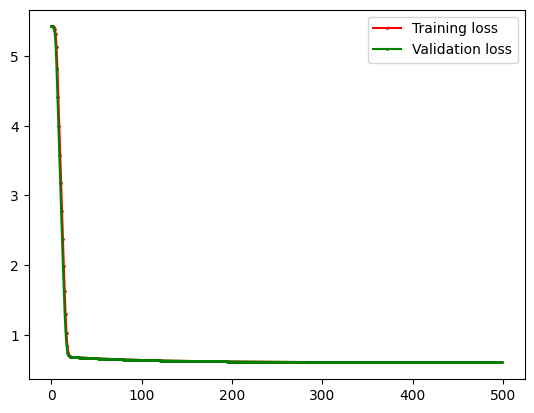

50. Training loss: 0.6651526207525984, Val loss:0.6643400326548693
100. Training loss: 0.6341585189654789, Val loss:0.6336996303590289
150. Training loss: 0.6162748817777743, Val loss:0.6160034445012508
200. Training loss: 0.6055193047414907, Val loss:0.6053530064624074
250. Training loss: 0.5988485101455817, Val loss:0.5987439680975944
300. Training loss: 0.5946168468398126, Val loss:0.5945498676627653
350. Training loss: 0.5918871302954763, Val loss:0.5918435986481247
400. Training loss: 0.5901036295551996, Val loss:0.5900750206771967
450. Training loss: 0.5889265635932869, Val loss:0.5889075932560319
500. Training loss: 0.5881433367692641, Val loss:0.5881306642072746


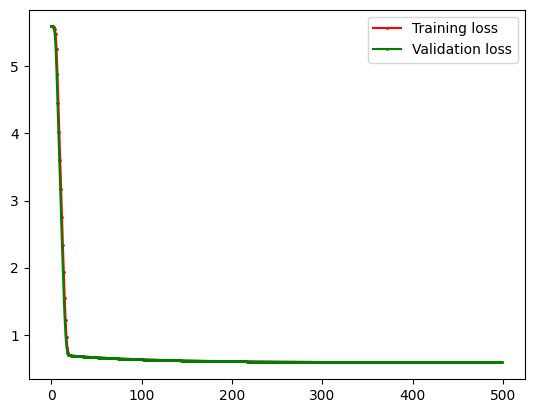

50. Training loss: 0.6542653003413582, Val loss:0.6536116317614128
100. Training loss: 0.6295006544929237, Val loss:0.6291373243445255
150. Training loss: 0.6154541739639984, Val loss:0.6152431623778146
200. Training loss: 0.6071653862631864, Val loss:0.6070386103364259
250. Training loss: 0.6021255119549752, Val loss:0.6020473937645502
300. Training loss: 0.598992028118016, Val loss:0.5989429734631948
350. Training loss: 0.5970108645925144, Val loss:0.5969796128683962
400. Training loss: 0.5957419392227286, Val loss:0.5957218023674267
450. Training loss: 0.5949207694012378, Val loss:0.5949076742322728
500. Training loss: 0.5943848179768196, Val loss:0.5943762358564174


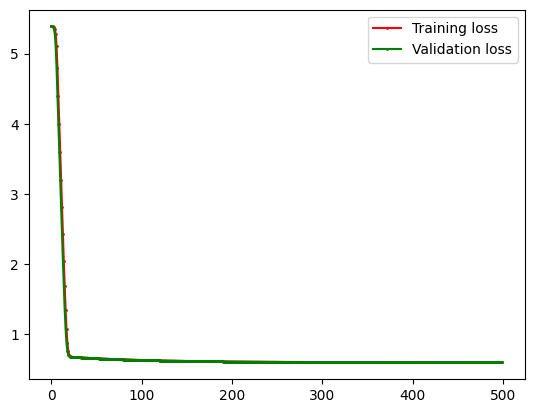

lr=0.1, λ=8.0 → avg accuracy=0.7229
50. Training loss: 0.6704161866944304, Val loss:0.6547776896812865
100. Training loss: 0.5391817825442081, Val loss:0.5372266068904972
150. Training loss: 0.5084926653199251, Val loss:0.508260159734587
200. Training loss: 0.49989688889813066, Val loss:0.4997696365255406
250. Training loss: 0.49485867336483996, Val loss:0.49478056789624064
300. Training loss: 0.49170220780999957, Val loss:0.4916521647570367
350. Training loss: 0.4896495104206425, Val loss:0.48961643536948934
400. Training loss: 0.48827741452029727, Val loss:0.4882550309187313
450. Training loss: 0.48734053226704777, Val loss:0.48732509815728253
500. Training loss: 0.48668985116998575, Val loss:0.48667904669445067


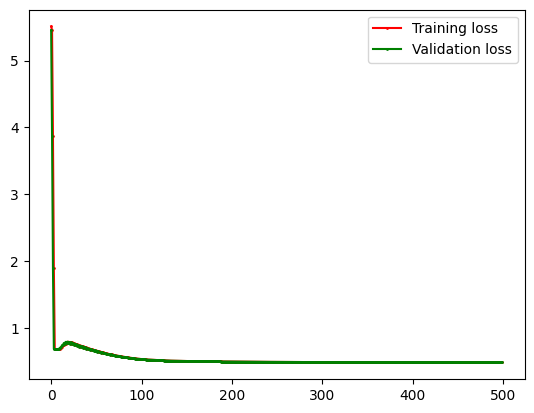

50. Training loss: 0.6233245248183505, Val loss:0.6281662748905201
100. Training loss: 0.5187420243053024, Val loss:0.5179847727621776
150. Training loss: 0.4977894937286565, Val loss:0.49753529494246507
200. Training loss: 0.4879322857526613, Val loss:0.4877821085002195
250. Training loss: 0.4819100319155394, Val loss:0.4818151943279601
300. Training loss: 0.47802923521949103, Val loss:0.4779667987917112
350. Training loss: 0.4754380025476203, Val loss:0.475395678063885
400. Training loss: 0.47366288825528924, Val loss:0.4736335624136615
450. Training loss: 0.4724228068830978, Val loss:0.47240213632291495
500. Training loss: 0.47154292158614675, Val loss:0.4715281487348942


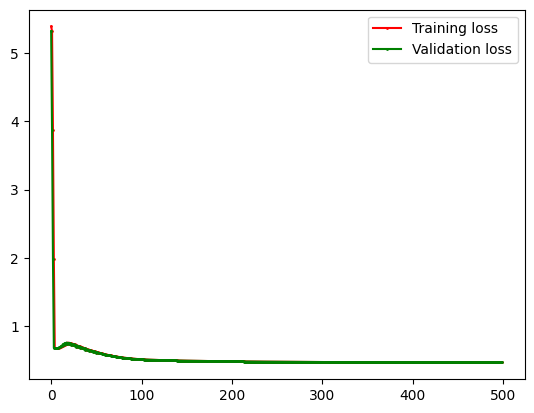

50. Training loss: 0.6822806061069463, Val loss:0.6654910458522002
100. Training loss: 0.557953484103464, Val loss:0.555528654585731
150. Training loss: 0.5225309890070688, Val loss:0.5222471835773579
200. Training loss: 0.512996518740949, Val loss:0.5128597981720097
250. Training loss: 0.5074666305133891, Val loss:0.5073789194534924
300. Training loss: 0.5038574172007951, Val loss:0.5037989799312547
350. Training loss: 0.5014196712025142, Val loss:0.5013796140339484
400. Training loss: 0.4997312274566368, Val loss:0.49970317068726056
450. Training loss: 0.49853903449739584, Val loss:0.4985190508628858
500. Training loss: 0.4976844564891935, Val loss:0.4976700332458091


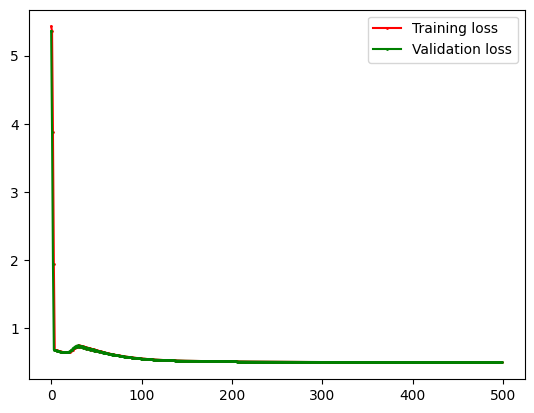

50. Training loss: 0.6466671707399587, Val loss:0.634924757188382
100. Training loss: 0.5233438939702882, Val loss:0.5224113025101679
150. Training loss: 0.5018586072013475, Val loss:0.501606809040952
200. Training loss: 0.4921261760267616, Val loss:0.49197894270693526
250. Training loss: 0.4862551767325163, Val loss:0.4861633408606027
300. Training loss: 0.48251723067496644, Val loss:0.4824574696224559
350. Training loss: 0.4800497853793993, Val loss:0.4800097278594943
400. Training loss: 0.47837845234486104, Val loss:0.4783510112481704
450. Training loss: 0.47722434228984856, Val loss:0.477205228801498
500. Training loss: 0.47641540623368966, Val loss:0.4764019173370105


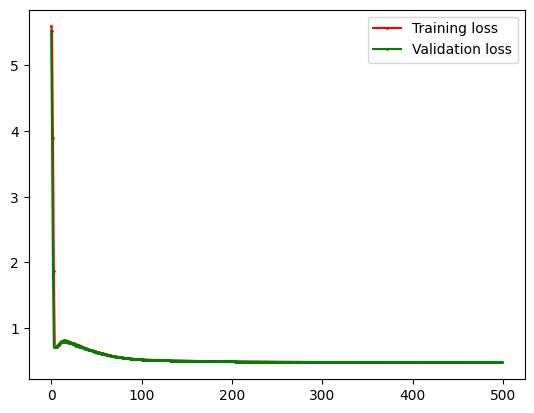

50. Training loss: 0.6317060305153658, Val loss:0.6367989393904052
100. Training loss: 0.5338885881685599, Val loss:0.5332436033736057
150. Training loss: 0.5167038741969081, Val loss:0.5165060584887613
200. Training loss: 0.50909603067697, Val loss:0.5089809255905047
250. Training loss: 0.504498285231135, Val loss:0.5044261625469973
300. Training loss: 0.501552836630835, Val loss:0.5015055300865775
350. Training loss: 0.4995904953879349, Val loss:0.49955844671375665
400. Training loss: 0.49824559652781836, Val loss:0.49822335654942446
450. Training loss: 0.49730399969361394, Val loss:0.4972882795054997
500. Training loss: 0.4966338059102179, Val loss:0.49662253295109987


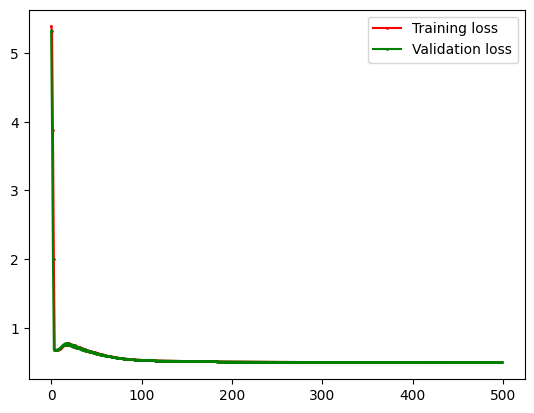

lr=0.5, λ=1.0 → avg accuracy=0.7257
50. Training loss: 0.6951180865348494, Val loss:0.6768733240874005
100. Training loss: 0.5855530417664917, Val loss:0.5803791225719214
150. Training loss: 0.5456680962643263, Val loss:0.544177652033843
200. Training loss: 0.5310473199228725, Val loss:0.5305357076850417
250. Training loss: 0.5250559218160433, Val loss:0.5248475442963492
300. Training loss: 0.5222952527920794, Val loss:0.5221986332208817
350. Training loss: 0.5208893185319251, Val loss:0.5208405023493279
400. Training loss: 0.520112579377862, Val loss:0.5200868122632781
450. Training loss: 0.5196542759770327, Val loss:0.5196407336348691
500. Training loss: 0.5193690269099707, Val loss:0.5193624814955635


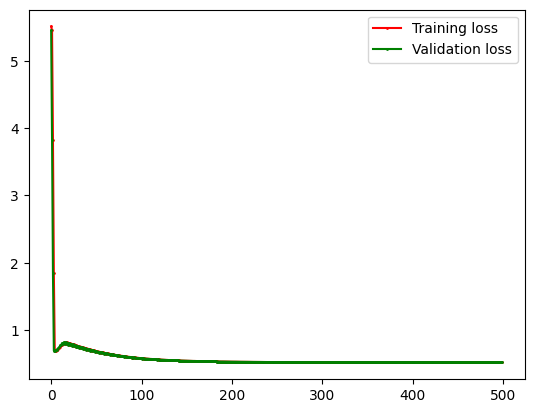

50. Training loss: 0.6459457164301307, Val loss:0.6546530478661859
100. Training loss: 0.551043741338607, Val loss:0.5514651662411333
150. Training loss: 0.5202902694536793, Val loss:0.5200410818517524
200. Training loss: 0.5119285803524491, Val loss:0.5118337229569571
250. Training loss: 0.5091979324033771, Val loss:0.5091596077567878
300. Training loss: 0.5078755691130478, Val loss:0.5078560745476288
350. Training loss: 0.5071496148326042, Val loss:0.5071388644230932
400. Training loss: 0.5067380762924824, Val loss:0.5067319373169805
450. Training loss: 0.5065000997981897, Val loss:0.5064965208600405
500. Training loss: 0.5063603214181827, Val loss:0.5063582043773066


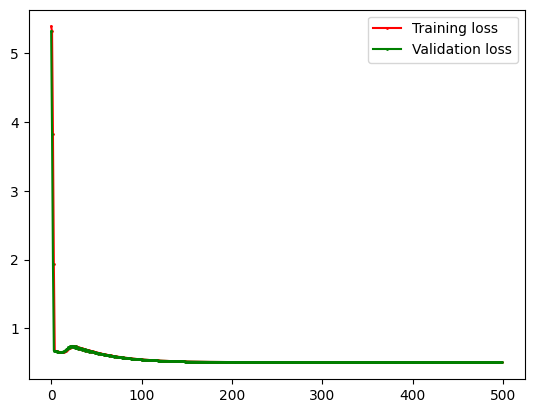

50. Training loss: 0.7023081079085128, Val loss:0.6830489500619065
100. Training loss: 0.6023236986583101, Val loss:0.5962229038694539
150. Training loss: 0.5657561280282769, Val loss:0.5633659159362839
200. Training loss: 0.5514329427650199, Val loss:0.5501723801486261
250. Training loss: 0.545138383518441, Val loss:0.5442932575396137
300. Training loss: 0.5421301670197417, Val loss:0.5414609867725902
350. Training loss: 0.5406074060304776, Val loss:0.540019682058107
400. Training loss: 0.5398004817736451, Val loss:0.5392528755177578
450. Training loss: 0.5393552384209593, Val loss:0.5388284589856386
500. Training loss: 0.5391009986537529, Val loss:0.5385855574681683


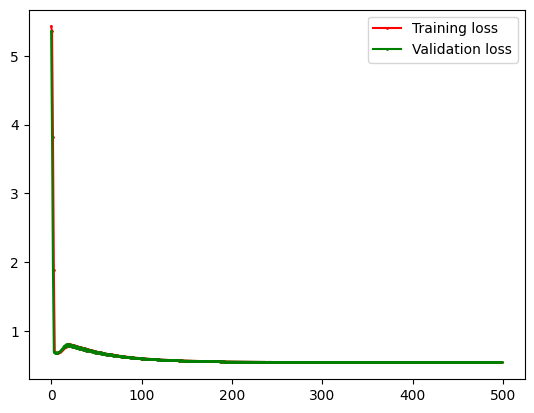

50. Training loss: 0.670915757613432, Val loss:0.6571174892399632
100. Training loss: 0.5565725756753442, Val loss:0.5540317707908788
150. Training loss: 0.522598331480745, Val loss:0.5222002271215077
200. Training loss: 0.5133859466378196, Val loss:0.5133024686626851
250. Training loss: 0.5104282406763616, Val loss:0.5103939027366532
300. Training loss: 0.5090519141436837, Val loss:0.509032817212067
350. Training loss: 0.5082984826302858, Val loss:0.5082874934611291
400. Training loss: 0.507870312866704, Val loss:0.5078639565640477
450. Training loss: 0.5076229966136631, Val loss:0.5076192894937407
500. Training loss: 0.507478360971857, Val loss:0.5074761783061983


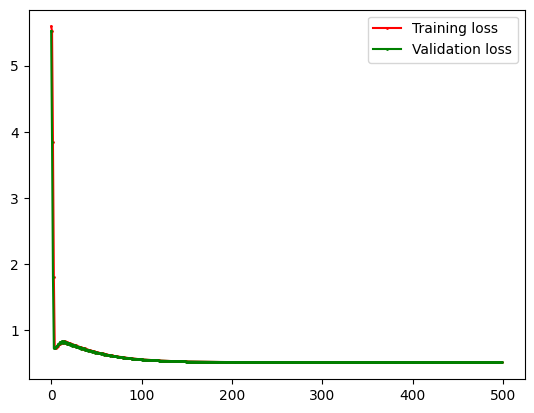

50. Training loss: 0.6544381633723821, Val loss:0.6638811704364525
100. Training loss: 0.5647136078276279, Val loss:0.5654440907922
150. Training loss: 0.5369926320772046, Val loss:0.5368505511005129
200. Training loss: 0.5286619908441565, Val loss:0.5285634382582955
250. Training loss: 0.5259012417520342, Val loss:0.5258585415091703
300. Training loss: 0.5247679873106701, Val loss:0.5247485877398081
350. Training loss: 0.5241923074135567, Val loss:0.5241824856289521
400. Training loss: 0.5238671082592585, Val loss:0.5238617543041281
450. Training loss: 0.5236761099532913, Val loss:0.5236730571989276
500. Training loss: 0.5235620693212437, Val loss:0.5235602785401783


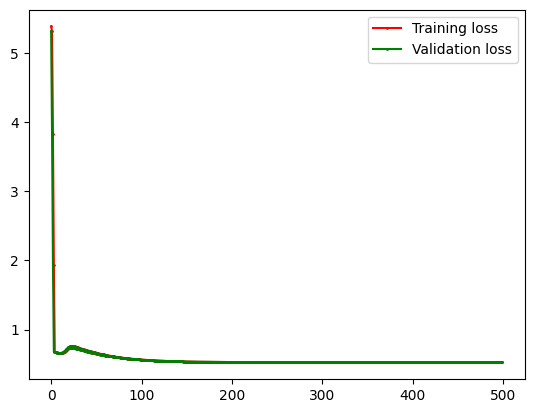

lr=0.5, λ=2.0 → avg accuracy=0.7343
50. Training loss: 0.7384136365101508, Val loss:0.7153723760351302
100. Training loss: 0.6727102298652572, Val loss:0.6587245493268936
150. Training loss: 0.6549882018265643, Val loss:0.6434723180492816
200. Training loss: 0.6504041306994716, Val loss:0.6395069445030572
250. Training loss: 0.6491578752408435, Val loss:0.6384233631889629
300. Training loss: 0.6487942258309368, Val loss:0.6381058941116301
350. Training loss: 0.648680631240267, Val loss:0.6380064861327732
400. Training loss: 0.648642968315571, Val loss:0.637973517427904
450. Training loss: 0.648629849250502, Val loss:0.6379620587299226
500. Training loss: 0.6486251003448716, Val loss:0.6379579313874081


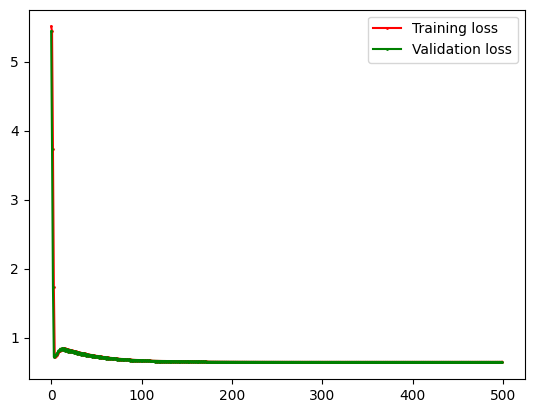

50. Training loss: 0.7002301984191334, Val loss:0.6804851693593768
100. Training loss: 0.6345576524905748, Val loss:0.6244830806089973
150. Training loss: 0.6176626239924665, Val loss:0.6099287348320775
200. Training loss: 0.613363143953776, Val loss:0.6061872221283533
250. Training loss: 0.6121834267643828, Val loss:0.605151218549635
300. Training loss: 0.6118271703459307, Val loss:0.6048357981373357
350. Training loss: 0.6117096506420779, Val loss:0.6047310420225216
400. Training loss: 0.6116679273177476, Val loss:0.6046936655821396
450. Training loss: 0.6116522436065057, Val loss:0.6046795748006499
500. Training loss: 0.6116460989738428, Val loss:0.6046740489282387


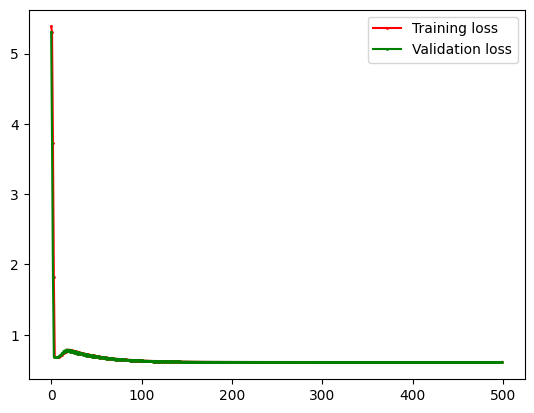

50. Training loss: 0.7438984085504149, Val loss:0.7189261649735499
100. Training loss: 0.6840257542724558, Val loss:0.6681136025772996
150. Training loss: 0.6680146625354363, Val loss:0.6544334034483168
200. Training loss: 0.6635879419399682, Val loss:0.6506044563194017
250. Training loss: 0.6622361828459883, Val loss:0.6494225014230947
300. Training loss: 0.6617850252058203, Val loss:0.6490245497308367
350. Training loss: 0.6616239725088566, Val loss:0.6488815218231714
400. Training loss: 0.6615635366496309, Val loss:0.6488275813791118
450. Training loss: 0.6615399988018549, Val loss:0.6488065034406403
500. Training loss: 0.6615305759280626, Val loss:0.6487980500050087


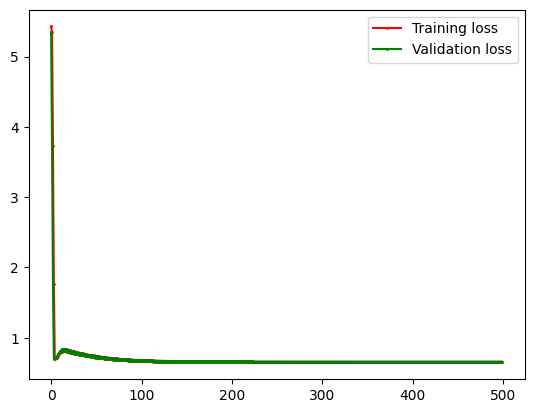

50. Training loss: 0.7143346097819315, Val loss:0.6966598015397376
100. Training loss: 0.6407565736231037, Val loss:0.6317916620571655
150. Training loss: 0.6225215505395226, Val loss:0.6156111590351862
200. Training loss: 0.6179629976201395, Val loss:0.6115196375075701
250. Training loss: 0.616672942807405, Val loss:0.6103488129040047
300. Training loss: 0.6162582383837167, Val loss:0.6099692206559587
350. Training loss: 0.6161123077556797, Val loss:0.6098348584372378
400. Training loss: 0.6160578530902096, Val loss:0.6097845206145587
450. Training loss: 0.616036727350742, Val loss:0.6097649400436909
500. Training loss: 0.6160283075583056, Val loss:0.609757123065986


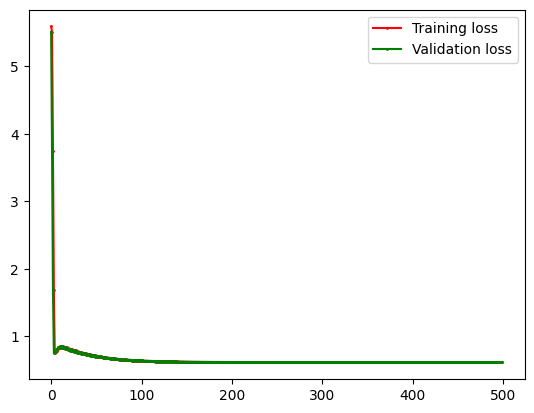

50. Training loss: 0.710327105009159, Val loss:0.6889795675828739
100. Training loss: 0.6475807465250901, Val loss:0.6363161826028962
150. Training loss: 0.6330265433766783, Val loss:0.6239289432988413
200. Training loss: 0.6296387359001853, Val loss:0.6209938776295544
250. Training loss: 0.6287363540270947, Val loss:0.6201976362585586
300. Training loss: 0.628457915274256, Val loss:0.6199481626361435
350. Training loss: 0.6283620093777426, Val loss:0.6198612796255324
400. Training loss: 0.6283264900498919, Val loss:0.6198288654247998
450. Training loss: 0.6283127120012667, Val loss:0.619816235054328
500. Training loss: 0.6283072078754486, Val loss:0.6198111770530309


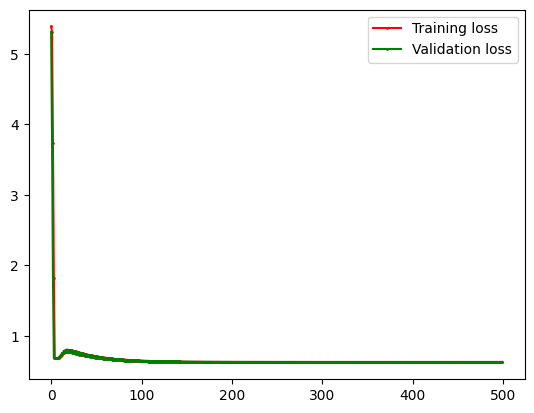

lr=0.5, λ=4.0 → avg accuracy=0.5600
50. Training loss: 0.8028933775892696, Val loss:0.7726559469801368
100. Training loss: 0.7797741477293143, Val loss:0.7529990514512177
150. Training loss: 0.7766400336385528, Val loss:0.7503710089996884
200. Training loss: 0.7762222721357835, Val loss:0.7500211285928726
250. Training loss: 0.7761646532439422, Val loss:0.7499729623050971
300. Training loss: 0.7761564073826251, Val loss:0.7499661107103953
350. Training loss: 0.7761551887084782, Val loss:0.7499651109219987
400. Training loss: 0.7761550038569057, Val loss:0.7499649626841026
450. Training loss: 0.7761549752979282, Val loss:0.7499649406384982
500. Training loss: 0.7761549708500934, Val loss:0.7499649374162548


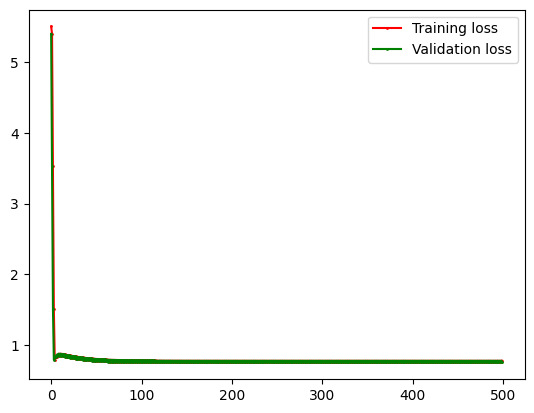

50. Training loss: 0.7659384876002091, Val loss:0.7381814191654109
100. Training loss: 0.7427498648782613, Val loss:0.7189704180080905
150. Training loss: 0.7397956178145273, Val loss:0.7165423860292746
200. Training loss: 0.7394154914273096, Val loss:0.7162293450786169
250. Training loss: 0.7393635570572026, Val loss:0.716186500222717
300. Training loss: 0.7393559922262506, Val loss:0.716180263648951
350. Training loss: 0.7393548199747659, Val loss:0.7161793013884652
400. Training loss: 0.7393546275896536, Val loss:0.7161791448604053
450. Training loss: 0.7393545943997187, Val loss:0.7161791182360329
500. Training loss: 0.7393545884425269, Val loss:0.7161791135525128


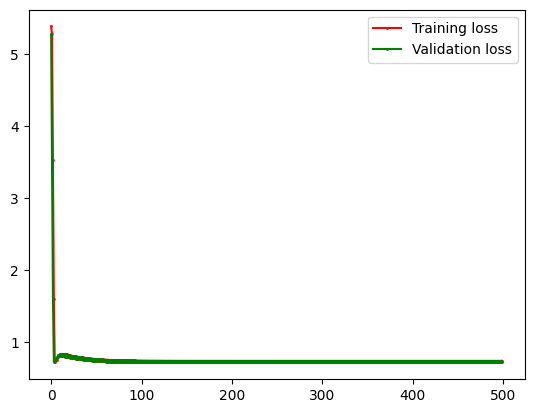

50. Training loss: 0.8068913380990793, Val loss:0.773122447227258
100. Training loss: 0.7855136216413504, Val loss:0.7552247801972404
150. Training loss: 0.7825968170823489, Val loss:0.7527941873357512
200. Training loss: 0.7821824152099394, Val loss:0.7524454534220778
250. Training loss: 0.7821186350284084, Val loss:0.7523912414763118
300. Training loss: 0.7821081073027263, Val loss:0.7523822266457184
350. Training loss: 0.7821062716267048, Val loss:0.7523806478775664
400. Training loss: 0.782105937809075, Val loss:0.7523803603640553
450. Training loss: 0.7821058751316473, Val loss:0.7523803064510171
500. Training loss: 0.7821058630771406, Val loss:0.7523802961222857


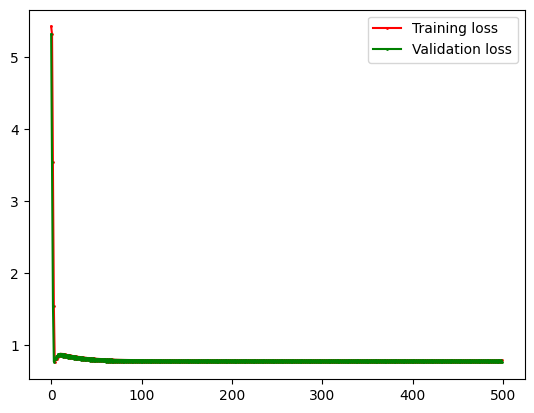

50. Training loss: 0.7808736279738626, Val loss:0.757121407326396
100. Training loss: 0.7530916999093638, Val loss:0.7330012601014962
150. Training loss: 0.7495326772701052, Val loss:0.7299198928103731
200. Training loss: 0.749059303736917, Val loss:0.7295064604145488
250. Training loss: 0.7489900603160555, Val loss:0.729445409609348
300. Training loss: 0.7489789762789693, Val loss:0.7294355640659709
350. Training loss: 0.7489770697378318, Val loss:0.7294338625921095
400. Training loss: 0.7489767237864413, Val loss:0.7294335532052292
450. Training loss: 0.7489766585380352, Val loss:0.7294334948610881
500. Training loss: 0.748976645886797, Val loss:0.7294334835713405


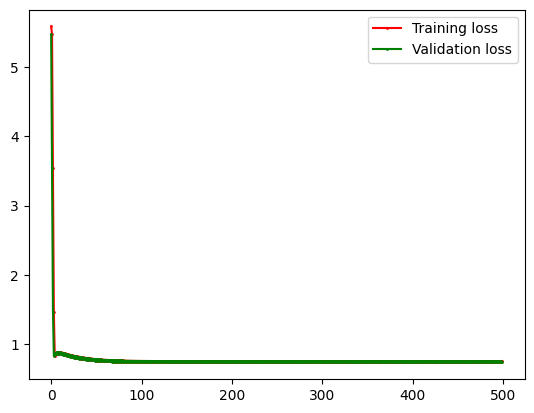

50. Training loss: 0.7773435482886185, Val loss:0.7463777571486473
100. Training loss: 0.7550123765994174, Val loss:0.7281498722059039
150. Training loss: 0.7523537403457964, Val loss:0.7259871207172974
200. Training loss: 0.7520303956129857, Val loss:0.7257207996177962
250. Training loss: 0.7519874834985047, Val loss:0.7256848895403186
300. Training loss: 0.7519812222236588, Val loss:0.7256795718306801
350. Training loss: 0.7519802271759636, Val loss:0.7256787174963484
400. Training loss: 0.7519800577284932, Val loss:0.7256785712033405
450. Training loss: 0.7519800273532699, Val loss:0.7256785449816539
500. Training loss: 0.751980021712867, Val loss:0.7256785401394096


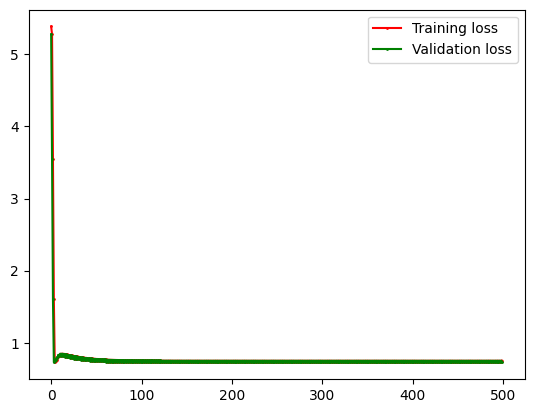

lr=0.5, λ=8.0 → avg accuracy=0.4629

5-Fold Cross Validation Average Accuracy with L2 Regularization:
           λ=1.0   λ=2.0   λ=4.0   λ=8.0
lr=0.005  0.5514  0.5543  0.5543  0.5543
lr=0.01   0.5943  0.5971  0.6029  0.6029
lr=0.1    0.7200  0.7314  0.7371  0.7229
lr=0.5    0.7257  0.7343  0.5600  0.4629


In [12]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.base import BaseEstimator, ClassifierMixin

#Wrap LinearModel to make it sklearn-compatible for cross_val_score
class LinearModelWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, lr=0.01, reg_lambda=1.0):
        self.lr = lr
        self.reg_lambda = reg_lambda

    def fit(self, X, y):
        np.random.seed(seed)
        self.model_ = LinearModel(
            dim=X.shape[1], is_reg=False,
            loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn
        )
        self.model_.fit(X, y, lr=self.lr, n_iteration=500,
                        val_ratio=0.0, reg_type='l2', reg_lambda=self.reg_lambda)
        return self

    def predict(self, X):
        return self.model_.predict(X)

#Hyperparameter grid
learning_rates = [0.005, 0.01, 0.1, 0.5]
reg_lambdas    = [1.0, 2.0, 4.0, 8.0]

kf = KFold(n_splits=5, shuffle=True, random_state=40)

cv_results = np.zeros((len(learning_rates), len(reg_lambdas)))

for i, lr in enumerate(learning_rates):
    for j, rl in enumerate(reg_lambdas):
        wrapper = LinearModelWrapper(lr=lr, reg_lambda=rl)
        scores = cross_val_score(wrapper, X_train, y_train,
                                 cv=kf, scoring='accuracy')
        cv_results[i, j] = scores.mean()
        print(f'lr={lr}, λ={rl} → avg accuracy={scores.mean():.4f}')

#format and print as4x4 table
cv_df = pd.DataFrame(
    cv_results,
    index=[f'lr={lr}' for lr in learning_rates],
    columns=[f'λ={rl}' for rl in reg_lambdas]
)
print('\n5-Fold Cross Validation Average Accuracy with L2 Regularization:')
print(cv_df.round(4))

#1b)

Best 2 hyperparameter settings:
  Rank 1: lr=0.1, reg_lambda=4.0, CV accuracy=0.7371
  Rank 2: lr=0.5, reg_lambda=2.0, CV accuracy=0.7343

--- Setting 1: lr=0.1, reg_lambda=4.0 ---
50. Training loss: 0.6568002102312084, Val loss:0.6692132793378223
100. Training loss: 0.626003876974164, Val loss:0.6457242702465912
150. Training loss: 0.6056656321431664, Val loss:0.6307571029788155
200. Training loss: 0.5917207345004456, Val loss:0.6208808201160417
250. Training loss: 0.5818660478757876, Val loss:0.6141749536440488
300. Training loss: 0.5747349381163848, Val loss:0.6095177784740045
350. Training loss: 0.5694780776853348, Val loss:0.6062260759895822
400. Training loss: 0.565545576304864, Val loss:0.6038678268569521
450. Training loss: 0.5625689103434711, Val loss:0.6021609046271765
500. Training loss: 0.5602939598802354, Val loss:0.6009159862132967


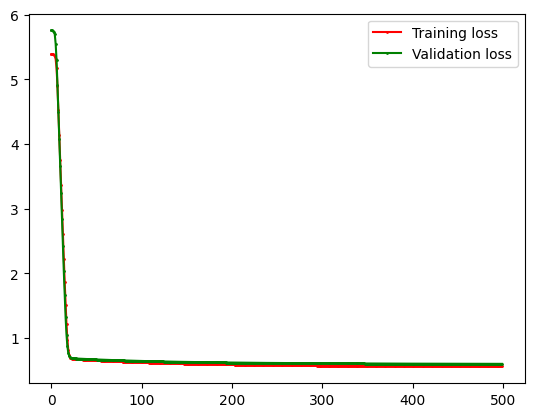

Model Evaluation
Accuracy  : 0.7400
Precision : 0.6989
Recall    : 0.8553
F1-score  : 0.7692


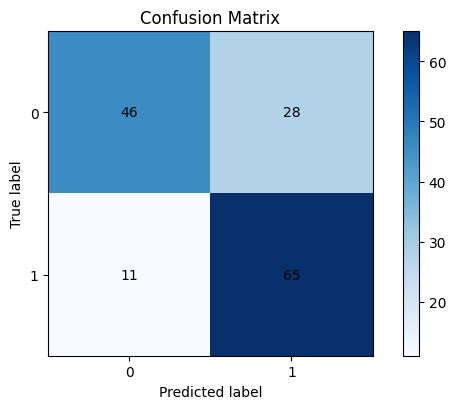


--- Setting 2: lr=0.5, reg_lambda=2.0 ---
50. Training loss: 0.6527163939314692, Val loss:0.7453608410779825
100. Training loss: 0.5595456093271856, Val loss:0.6349156228795745
150. Training loss: 0.529596735430504, Val loss:0.5965768883743758
200. Training loss: 0.5207348462555711, Val loss:0.5839222620328327
250. Training loss: 0.5179261123498633, Val loss:0.580122885302211
300. Training loss: 0.5167200032888141, Val loss:0.579152190207065
350. Training loss: 0.5160809091266559, Val loss:0.5789859854701844
400. Training loss: 0.5157197466608066, Val loss:0.5790165750466023
450. Training loss: 0.5155105621565736, Val loss:0.5790797235252148
500. Training loss: 0.5153873917667308, Val loss:0.5791364795527456


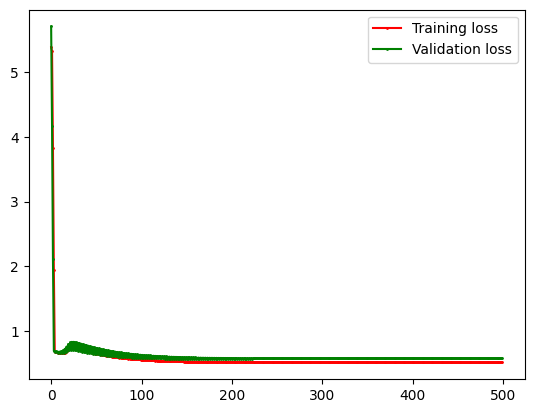

Model Evaluation
Accuracy  : 0.7533
Precision : 0.7294
Recall    : 0.8158
F1-score  : 0.7702


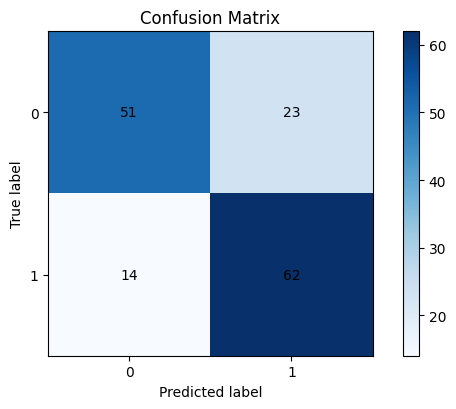

In [13]:
from model.metrics import evaluate_binary_classifier

#results from 2a, rank 
all_results = [
    (cv_results[i, j], learning_rates[i], reg_lambdas[j])
    for i in range(len(learning_rates))
    for j in range(len(reg_lambdas))
]
all_results.sort(reverse=True)
top2 = all_results[:2]

print('Best 2 hyperparameter settings:')
for rank, (acc, lr, rl) in enumerate(top2, 1):
    print(f'  Rank {rank}: lr={lr}, reg_lambda={rl}, CV accuracy={acc:.4f}')

#train model for each setting
for rank, (acc, lr, rl) in enumerate(top2, 1):
    print(f'\n--- Setting {rank}: lr={lr}, reg_lambda={rl} ---')
    np.random.seed(seed)
    model_top = LinearModel(
        dim=X_train.shape[1], is_reg=False,
        loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn
    )
    model_top.fit(X_train, y_train, lr=lr, n_iteration=500,
                  val_ratio=0.2, reg_type='l2', reg_lambda=rl)
    y_pred_top = model_top.predict(X_test)
    evaluate_binary_classifier(y_test, y_pred_top)